<a href="https://colab.research.google.com/github/fakhar-nadeem/Data-Science/blob/main/Assessment_DAS7005%20FINAL%20VERSION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Here is the link that will showcase the following as an application : https://st20319060das7005.streamlit.app/**

**Github link for the project: https://github.com/fakhar-nadeem/Data-Science/commits?author=fakhar-nadeem**


# **Importing libraries and mounting drive:**

Importing basic libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn import preprocessing
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

### **Mounting the google drive to the colab environment:**

Mounting the drive to access the provided datasets

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd '/content/drive/MyDrive/Assessment Data-20250304/'

/content/drive/MyDrive/Assessment Data-20250304


In [4]:
%ls

Assessment_combined.csv
combined_output.csv
PRSA_Data_Aotizhongxin_20130301-20170228.csv
PRSA_Data_Changping_20130301-20170228.csv
PRSA_Data_Dingling_20130301-20170228.csv
PRSA_Data_Dongsi_20130301-20170228.csv
PRSA_Data_Guanyuan_20130301-20170228.csv
PRSA_Data_Gucheng_20130301-20170228.csv
PRSA_Data_Huairou_20130301-20170228.csv
PRSA_Data_Nongzhanguan_20130301-20170228.csv
PRSA_Data_Shunyi_20130301-20170228.csv
PRSA_Data_Tiantan_20130301-20170228.csv
PRSA_Data_Wanliu_20130301-20170228.csv
PRSA_Data_Wanshouxigong_20130301-20170228.csv
Transformed_dataset.csv


### **Loading the Pandas dataframe:**

I choose the following datasets. Simply, by checking which one of them are urban cities, suburban and etc.

In [5]:
# Load the CSV file into a pandas DataFrame
urban_df = pd.read_csv("PRSA_Data_Dongsi_20130301-20170228.csv")
suburban_df = pd.read_csv("PRSA_Data_Shunyi_20130301-20170228.csv")
rural_df = pd.read_csv("PRSA_Data_Huairou_20130301-20170228.csv")
industrial_df = pd.read_csv("PRSA_Data_Guanyuan_20130301-20170228.csv")


# **Data Cleaning:**

## Cleaning Urban Dataset:



### **Checking Null Values:**

In [6]:
# Checking if data has null values
urban_df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,750
PM10,553
SO2,663
NO2,1601
CO,3197


**Handling Null values:**

In [7]:
# Removing columns with too many missing values
urban_df.dropna(axis=1, thresh=0.9*len(urban_df), inplace=True)  # This will keep columns with at least 90% non-null values
# Removing all rows with missing values because they are not that much in quantity in relation to whole data
urban_df.dropna(inplace=True)
urban_df.isnull().sum() # Checking if there are any missing values left

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


In [8]:
urban_df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
5,6,2013,3,1,5,4.0,4.0,9.0,25.0,300.0,78.0,-2.4,1027.5,-21.3,0.0,NW,2.4,Dongsi
6,7,2013,3,1,6,5.0,5.0,10.0,29.0,400.0,67.0,-2.5,1028.2,-20.4,0.0,NW,2.2,Dongsi
7,8,2013,3,1,7,3.0,6.0,12.0,40.0,400.0,52.0,-1.4,1029.5,-20.4,0.0,NNW,3.0,Dongsi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,16.0,51.0,3.0,29.0,400.0,73.0,12.5,1013.5,-16.2,0.0,NW,2.4,Dongsi
35060,35061,2017,2,28,20,18.0,45.0,3.0,43.0,500.0,54.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Dongsi
35061,35062,2017,2,28,21,23.0,58.0,5.0,61.0,700.0,28.0,10.8,1014.2,-13.3,0.0,NW,1.1,Dongsi
35062,35063,2017,2,28,22,23.0,53.0,9.0,75.0,900.0,15.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Dongsi


### **Removing Duplicates:**

In [9]:
#Removes any duplicates in the data
urban_df.drop_duplicates(inplace=True)

In [10]:
urban_df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2,2013,3,1,1,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
5,6,2013,3,1,5,4.0,4.0,9.0,25.0,300.0,78.0,-2.4,1027.5,-21.3,0.0,NW,2.4,Dongsi
6,7,2013,3,1,6,5.0,5.0,10.0,29.0,400.0,67.0,-2.5,1028.2,-20.4,0.0,NW,2.2,Dongsi
7,8,2013,3,1,7,3.0,6.0,12.0,40.0,400.0,52.0,-1.4,1029.5,-20.4,0.0,NNW,3.0,Dongsi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,16.0,51.0,3.0,29.0,400.0,73.0,12.5,1013.5,-16.2,0.0,NW,2.4,Dongsi
35060,35061,2017,2,28,20,18.0,45.0,3.0,43.0,500.0,54.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Dongsi
35061,35062,2017,2,28,21,23.0,58.0,5.0,61.0,700.0,28.0,10.8,1014.2,-13.3,0.0,NW,1.1,Dongsi
35062,35063,2017,2,28,22,23.0,53.0,9.0,75.0,900.0,15.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Dongsi


### **Handling Outliers:**

A z-score measures how many standard deviations a data point has from the mean in a distribution

Removing outliers with Z-score > 3 because data points with a Z-score greater than 3 are considered outliers and can be removed from a dataset

####Temperature:

In [11]:
from scipy import stats

# Remove outliers with Z-score > 3
urban_df = urban_df[(np.abs(stats.zscore(urban_df['TEMP'])) < 3)]

####PM2.5:

In [12]:
urban_df = urban_df[(np.abs(stats.zscore(urban_df['PM2.5'])) < 3)]

####PM10:

In [13]:
urban_df = urban_df[(np.abs(stats.zscore(urban_df['PM10'])) < 3)]

####SO2:

In [14]:
urban_df = urban_df[(np.abs(stats.zscore(urban_df['SO2'])) < 3)]

####NO2:

In [15]:
urban_df = urban_df[(np.abs(stats.zscore(urban_df['NO2'])) < 3)]

####CO:

In [16]:
urban_df = urban_df[(np.abs(stats.zscore(urban_df['CO'])) < 3)]

####O3:

In [17]:
urban_df = urban_df[(np.abs(stats.zscore(urban_df['O3'])) < 3)]

### **Correcting Data Types:**

In [18]:
#Creating a datetime column
urban_df['datetime'] = pd.to_datetime(urban_df[['year', 'month', 'day', 'hour']])

#Dropping the individual columns
urban_df.drop(['year', 'month', 'day', 'hour'], axis=1, inplace=True)

#Rearanging the columns
new_order = ['datetime','No',	'PM2.5',	'PM10', 'SO2',	'NO2'	,'CO',	'O3',	'TEMP',	'PRES',	'DEWP',	'RAIN',	'wd',	'WSPM',	'station'	]
urban_df = urban_df[new_order]
urban_df

,datetime,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,2013-03-01 00:00:00,1,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2013-03-01 01:00:00,2,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
5,2013-03-01 05:00:00,6,4.0,4.0,9.0,25.0,300.0,78.0,-2.4,1027.5,-21.3,0.0,NW,2.4,Dongsi
6,2013-03-01 06:00:00,7,5.0,5.0,10.0,29.0,400.0,67.0,-2.5,1028.2,-20.4,0.0,NW,2.2,Dongsi
7,2013-03-01 07:00:00,8,3.0,6.0,12.0,40.0,400.0,52.0,-1.4,1029.5,-20.4,0.0,NNW,3.0,Dongsi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2017-02-28 19:00:00,35060,16.0,51.0,3.0,29.0,400.0,73.0,12.5,1013.5,-16.2,0.0,NW,2.4,Dongsi
35060,2017-02-28 20:00:00,35061,18.0,45.0,3.0,43.0,500.0,54.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Dongsi
35061,2017-02-28 21:00:00,35062,23.0,58.0,5.0,61.0,700.0,28.0,10.8,1014.2,-13.3,0.0,NW,1.1,Dongsi
35062,2017-02-28 22:00:00,35063,23.0,53.0,9.0,75.0,900.0,15.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Dongsi


## Cleaning Suburban Dataset:



### **Checking Null Values:**

In [19]:
# Checking if data has null values
suburban_df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,913
PM10,548
SO2,1296
NO2,1365
CO,2178


**Handling Null values:**

In [20]:
# Removing columns with too many missing values
suburban_df.dropna(axis=1, thresh=0.9*len(suburban_df), inplace=True)  # This will keep columns with at least 90% non-null values
# Removing all rows with missing values because they are not that much in quantity in relation to whole data
suburban_df.dropna(inplace=True)
suburban_df.isnull().sum() # Checking if there are any missing values left

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


In [21]:
suburban_df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,3.0,8.0,300.0,44.0,-0.9,1025.8,-20.5,0.0,NW,9.3,Shunyi
1,2,2013,3,1,1,12.0,12.0,3.0,7.0,300.0,47.0,-1.1,1026.1,-21.3,0.0,NW,9.4,Shunyi
5,6,2013,3,1,5,11.0,11.0,3.0,7.0,200.0,45.0,-2.8,1028.2,-22.1,0.0,NNW,1.7,Shunyi
6,7,2013,3,1,6,12.0,12.0,3.0,9.0,300.0,74.0,-4.0,1029.0,-21.2,0.0,NNE,1.6,Shunyi
7,8,2013,3,1,7,13.0,13.0,3.0,23.0,300.0,59.0,-2.4,1030.5,-21.3,0.0,NE,1.7,Shunyi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,27.0,72.0,8.0,92.0,800.0,16.0,10.3,1014.2,-12.4,0.0,W,1.8,Shunyi
35060,35061,2017,2,28,20,47.0,55.0,17.0,86.0,1100.0,19.0,9.8,1014.5,-9.9,0.0,NW,1.5,Shunyi
35061,35062,2017,2,28,21,18.0,28.0,4.0,30.0,500.0,64.0,9.1,1014.6,-12.7,0.0,NE,1.7,Shunyi
35062,35063,2017,2,28,22,18.0,20.0,9.0,33.0,500.0,59.0,7.1,1015.2,-13.2,0.0,WNW,1.8,Shunyi


###**Removing Duplicates:**

In [22]:
#Removes any duplicates in the data
suburban_df.drop_duplicates(inplace=True)

In [23]:
suburban_df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,3.0,8.0,300.0,44.0,-0.9,1025.8,-20.5,0.0,NW,9.3,Shunyi
1,2,2013,3,1,1,12.0,12.0,3.0,7.0,300.0,47.0,-1.1,1026.1,-21.3,0.0,NW,9.4,Shunyi
5,6,2013,3,1,5,11.0,11.0,3.0,7.0,200.0,45.0,-2.8,1028.2,-22.1,0.0,NNW,1.7,Shunyi
6,7,2013,3,1,6,12.0,12.0,3.0,9.0,300.0,74.0,-4.0,1029.0,-21.2,0.0,NNE,1.6,Shunyi
7,8,2013,3,1,7,13.0,13.0,3.0,23.0,300.0,59.0,-2.4,1030.5,-21.3,0.0,NE,1.7,Shunyi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,27.0,72.0,8.0,92.0,800.0,16.0,10.3,1014.2,-12.4,0.0,W,1.8,Shunyi
35060,35061,2017,2,28,20,47.0,55.0,17.0,86.0,1100.0,19.0,9.8,1014.5,-9.9,0.0,NW,1.5,Shunyi
35061,35062,2017,2,28,21,18.0,28.0,4.0,30.0,500.0,64.0,9.1,1014.6,-12.7,0.0,NE,1.7,Shunyi
35062,35063,2017,2,28,22,18.0,20.0,9.0,33.0,500.0,59.0,7.1,1015.2,-13.2,0.0,WNW,1.8,Shunyi


### **Handling Outliers:**

Using Z-score

A z-score measures how many standard deviations a data point is from the mean in a distribution

####Temperature:

In [24]:
# Remove outliers with Z-score > 3
suburban_df = suburban_df[(np.abs(stats.zscore(suburban_df['TEMP'])) < 3)]

####PM2.5:

In [25]:
# Remove outliers with Z-score > 3
suburban_df = suburban_df[(np.abs(stats.zscore(suburban_df['PM2.5'])) < 3)]

####PM10:

In [26]:
# Remove outliers with Z-score > 3
suburban_df = suburban_df[(np.abs(stats.zscore(suburban_df['PM10'])) < 3)]

####SO2:

In [27]:
# Remove outliers with Z-score > 3
suburban_df = suburban_df[(np.abs(stats.zscore(suburban_df['SO2'])) < 3)]

####NO2:

In [28]:
# Remove outliers with Z-score > 3
suburban_df = suburban_df[(np.abs(stats.zscore(suburban_df['NO2'])) < 3)]

####CO:

In [29]:
# Remove outliers with Z-score > 3
suburban_df = suburban_df[(np.abs(stats.zscore(suburban_df['CO'])) < 3)]

####O3:

In [30]:
# Remove outliers with Z-score > 3
suburban_df = suburban_df[(np.abs(stats.zscore(suburban_df['O3'])) < 3)]

### **Correcting Data Types:**

In [31]:
#Creating a datetime column
suburban_df['datetime'] = pd.to_datetime(suburban_df[['year', 'month', 'day', 'hour']])

#Dropping the individual columns
suburban_df.drop(['year', 'month', 'day', 'hour'], axis=1, inplace=True)

#Rearanging the columns
new_order = ['datetime','No',	'PM2.5',	'PM10', 'SO2',	'NO2'	,'CO',	'O3',	'TEMP',	'PRES',	'DEWP',	'RAIN',	'wd',	'WSPM',	'station'	]
suburban_df = suburban_df[new_order]
suburban_df

,datetime,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,2013-03-01 00:00:00,1,3.0,6.0,3.0,8.0,300.0,44.0,-0.9,1025.8,-20.5,0.0,NW,9.3,Shunyi
1,2013-03-01 01:00:00,2,12.0,12.0,3.0,7.0,300.0,47.0,-1.1,1026.1,-21.3,0.0,NW,9.4,Shunyi
5,2013-03-01 05:00:00,6,11.0,11.0,3.0,7.0,200.0,45.0,-2.8,1028.2,-22.1,0.0,NNW,1.7,Shunyi
6,2013-03-01 06:00:00,7,12.0,12.0,3.0,9.0,300.0,74.0,-4.0,1029.0,-21.2,0.0,NNE,1.6,Shunyi
7,2013-03-01 07:00:00,8,13.0,13.0,3.0,23.0,300.0,59.0,-2.4,1030.5,-21.3,0.0,NE,1.7,Shunyi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2017-02-28 19:00:00,35060,27.0,72.0,8.0,92.0,800.0,16.0,10.3,1014.2,-12.4,0.0,W,1.8,Shunyi
35060,2017-02-28 20:00:00,35061,47.0,55.0,17.0,86.0,1100.0,19.0,9.8,1014.5,-9.9,0.0,NW,1.5,Shunyi
35061,2017-02-28 21:00:00,35062,18.0,28.0,4.0,30.0,500.0,64.0,9.1,1014.6,-12.7,0.0,NE,1.7,Shunyi
35062,2017-02-28 22:00:00,35063,18.0,20.0,9.0,33.0,500.0,59.0,7.1,1015.2,-13.2,0.0,WNW,1.8,Shunyi


In [32]:
print(suburban_df.dtypes)

datetime    datetime64[ns]
No                   int64
PM2.5              float64
PM10               float64
SO2                float64
NO2                float64
CO                 float64
O3                 float64
TEMP               float64
PRES               float64
DEWP               float64
RAIN               float64
wd                  object
WSPM               float64
station             object
dtype: object


## Cleaning Rural Dataset:



### **Checking Null Values:**

In [33]:
# Checking if data has null values
rural_df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,953
PM10,777
SO2,980
NO2,1639
CO,1422


**Handling Null values:**

In [34]:
# Removing columns with too many missing values
rural_df.dropna(axis=1, thresh=0.9*len(rural_df), inplace=True)  # This will keep columns with at least 90% non-null values
# Removing all rows with missing values because they are not that much in quantity in relation to whole data
rural_df.dropna(inplace=True)
rural_df.isnull().sum() # Checking if there are any missing values left

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


In [35]:
rural_df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou
5,6,2013,3,1,5,4.0,4.0,3.0,3.0,200.0,85.0,-4.2,1022.3,-24.5,0.0,N,4.3,Huairou
6,7,2013,3,1,6,3.0,6.0,33.0,7.0,300.0,82.0,-5.9,1023.1,-21.9,0.0,WNW,0.6,Huairou
7,8,2013,3,1,7,3.0,10.0,13.0,13.0,400.0,71.0,-2.7,1024.3,-23.2,0.0,NNE,3.4,Huairou
8,9,2013,3,1,8,3.0,13.0,34.0,38.0,800.0,45.0,-1.6,1025.2,-23.5,0.0,NNE,4.6,Huairou
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,16.0,28.0,2.0,19.0,300.0,95.0,9.9,1008.6,-14.1,0.0,WNW,1.8,Huairou
35060,35061,2017,2,28,20,21.0,34.0,4.0,24.0,500.0,80.0,9.5,1008.9,-14.4,0.0,SSW,1.3,Huairou
35061,35062,2017,2,28,21,17.0,33.0,2.0,39.0,900.0,60.0,8.4,1009.3,-14.6,0.0,SE,1.5,Huairou
35062,35063,2017,2,28,22,11.0,29.0,3.0,32.0,1400.0,69.0,8.3,1009.5,-14.7,0.0,ENE,3.2,Huairou


### **Removing Duplicates:**

In [36]:
#Removes any duplicates in the data
rural_df.drop_duplicates(inplace=True)

In [37]:
rural_df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou
5,6,2013,3,1,5,4.0,4.0,3.0,3.0,200.0,85.0,-4.2,1022.3,-24.5,0.0,N,4.3,Huairou
6,7,2013,3,1,6,3.0,6.0,33.0,7.0,300.0,82.0,-5.9,1023.1,-21.9,0.0,WNW,0.6,Huairou
7,8,2013,3,1,7,3.0,10.0,13.0,13.0,400.0,71.0,-2.7,1024.3,-23.2,0.0,NNE,3.4,Huairou
8,9,2013,3,1,8,3.0,13.0,34.0,38.0,800.0,45.0,-1.6,1025.2,-23.5,0.0,NNE,4.6,Huairou
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,16.0,28.0,2.0,19.0,300.0,95.0,9.9,1008.6,-14.1,0.0,WNW,1.8,Huairou
35060,35061,2017,2,28,20,21.0,34.0,4.0,24.0,500.0,80.0,9.5,1008.9,-14.4,0.0,SSW,1.3,Huairou
35061,35062,2017,2,28,21,17.0,33.0,2.0,39.0,900.0,60.0,8.4,1009.3,-14.6,0.0,SE,1.5,Huairou
35062,35063,2017,2,28,22,11.0,29.0,3.0,32.0,1400.0,69.0,8.3,1009.5,-14.7,0.0,ENE,3.2,Huairou


### **Handling Outliers:**

Using Z-score

A z-score measures how many standard deviations a data point is from the mean in a distribution

####Temperature:

In [38]:
# Remove outliers with Z-score > 3
rural_df = rural_df[(np.abs(stats.zscore(rural_df['TEMP'])) < 3)]

####PM2.5:

In [39]:
# Remove outliers with Z-score > 3
rural_df = rural_df[(np.abs(stats.zscore(rural_df['PM2.5'])) < 3)]

####PM10:

In [40]:
# Remove outliers with Z-score > 3
rural_df = rural_df[(np.abs(stats.zscore(rural_df['PM10'])) < 3)]

####SO2:

In [41]:
# Remove outliers with Z-score > 3
rural_df = rural_df[(np.abs(stats.zscore(rural_df['SO2'])) < 3)]

####NO2:

In [42]:
# Remove outliers with Z-score > 3
rural_df = rural_df[(np.abs(stats.zscore(rural_df['NO2'])) < 3)]

####CO:

In [43]:
# Remove outliers with Z-score > 3
rural_df = rural_df[(np.abs(stats.zscore(rural_df['CO'])) < 3)]

####O3:

In [44]:
# Remove outliers with Z-score > 3
rural_df = rural_df[(np.abs(stats.zscore(rural_df['O3'])) < 3)]

### **Correcting Data Types:**

In [45]:
#Creating a datetime column
rural_df['datetime'] = pd.to_datetime(rural_df[['year', 'month', 'day', 'hour']])

#Dropping the individual columns
rural_df.drop(['year', 'month', 'day', 'hour'], axis=1, inplace=True)

#Rearanging the columns
new_order = ['datetime','No',	'PM2.5',	'PM10', 'SO2',	'NO2'	,'CO',	'O3',	'TEMP',	'PRES',	'DEWP',	'RAIN',	'wd',	'WSPM',	'station'	]
rural_df = rural_df[new_order]
rural_df

,datetime,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,2013-03-01 00:00:00,1,7.0,7.0,3.0,2.0,100.0,91.0,-2.3,1020.3,-20.7,0.0,WNW,3.1,Huairou
5,2013-03-01 05:00:00,6,4.0,4.0,3.0,3.0,200.0,85.0,-4.2,1022.3,-24.5,0.0,N,4.3,Huairou
6,2013-03-01 06:00:00,7,3.0,6.0,33.0,7.0,300.0,82.0,-5.9,1023.1,-21.9,0.0,WNW,0.6,Huairou
7,2013-03-01 07:00:00,8,3.0,10.0,13.0,13.0,400.0,71.0,-2.7,1024.3,-23.2,0.0,NNE,3.4,Huairou
8,2013-03-01 08:00:00,9,3.0,13.0,34.0,38.0,800.0,45.0,-1.6,1025.2,-23.5,0.0,NNE,4.6,Huairou
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2017-02-28 19:00:00,35060,16.0,28.0,2.0,19.0,300.0,95.0,9.9,1008.6,-14.1,0.0,WNW,1.8,Huairou
35060,2017-02-28 20:00:00,35061,21.0,34.0,4.0,24.0,500.0,80.0,9.5,1008.9,-14.4,0.0,SSW,1.3,Huairou
35061,2017-02-28 21:00:00,35062,17.0,33.0,2.0,39.0,900.0,60.0,8.4,1009.3,-14.6,0.0,SE,1.5,Huairou
35062,2017-02-28 22:00:00,35063,11.0,29.0,3.0,32.0,1400.0,69.0,8.3,1009.5,-14.7,0.0,ENE,3.2,Huairou


In [46]:
print(rural_df.dtypes)

datetime    datetime64[ns]
No                   int64
PM2.5              float64
PM10               float64
SO2                float64
NO2                float64
CO                 float64
O3                 float64
TEMP               float64
PRES               float64
DEWP               float64
RAIN               float64
wd                  object
WSPM               float64
station             object
dtype: object


## Cleaning Industrial Dataset:



### **Checking Null Values:**

In [47]:
# Checking if data has null values
industrial_df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,616
PM10,429
SO2,474
NO2,659
CO,1753


**Handling Null values:**

In [48]:
# Removing columns with too many missing values
industrial_df.dropna(axis=1, thresh=0.9*len(industrial_df), inplace=True)  # This will keep columns with at least 90% non-null values
# Removing all rows with missing values because they are not that much in quantity in relation to whole data
industrial_df.dropna(inplace=True)
industrial_df.isnull().sum() # Checking if there are any missing values left

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


In [49]:
industrial_df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
1,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2,3,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
3,4,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
4,5,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,13.0,37.0,3.0,36.0,400.0,60.0,12.5,1013.5,-16.2,0.0,NW,2.4,Guanyuan
35060,35061,2017,2,28,20,20.0,43.0,4.0,48.0,500.0,43.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Guanyuan
35061,35062,2017,2,28,21,16.0,33.0,5.0,39.0,500.0,50.0,10.8,1014.2,-13.3,0.0,NW,1.1,Guanyuan
35062,35063,2017,2,28,22,11.0,24.0,5.0,47.0,500.0,41.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Guanyuan


### **Removing Duplicates:**

In [50]:
#Removes any duplicates in the data
industrial_df.drop_duplicates(inplace=True)

In [51]:
industrial_df

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
1,2,2013,3,1,1,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2,3,2013,3,1,2,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
3,4,2013,3,1,3,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
4,5,2013,3,1,4,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,35060,2017,2,28,19,13.0,37.0,3.0,36.0,400.0,60.0,12.5,1013.5,-16.2,0.0,NW,2.4,Guanyuan
35060,35061,2017,2,28,20,20.0,43.0,4.0,48.0,500.0,43.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Guanyuan
35061,35062,2017,2,28,21,16.0,33.0,5.0,39.0,500.0,50.0,10.8,1014.2,-13.3,0.0,NW,1.1,Guanyuan
35062,35063,2017,2,28,22,11.0,24.0,5.0,47.0,500.0,41.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Guanyuan


### **Handling Outliers:**

Using Z-score

A z-score measures how many standard deviations a data point is from the mean in a distribution

####Temperature:

In [52]:
# Remove outliers with Z-score > 3
industrial_df = industrial_df[(np.abs(stats.zscore(industrial_df['TEMP'])) < 3)]

####PM2.5:

In [53]:
# Remove outliers with Z-score > 3
industrial_df = industrial_df[(np.abs(stats.zscore(industrial_df['PM2.5'])) < 3)]

####PM10:

In [54]:
# Remove outliers with Z-score > 3
industrial_df = industrial_df[(np.abs(stats.zscore(industrial_df['PM10'])) < 3)]

####SO2:

In [55]:
# Remove outliers with Z-score > 3
industrial_df = industrial_df[(np.abs(stats.zscore(industrial_df['SO2'])) < 3)]

####NO2:

In [56]:
# Remove outliers with Z-score > 3
industrial_df = industrial_df[(np.abs(stats.zscore(industrial_df['NO2'])) < 3)]

####CO:

In [57]:
# Remove outliers with Z-score > 3
industrial_df = industrial_df[(np.abs(stats.zscore(industrial_df['CO'])) < 3)]

####O3:

In [58]:
# Remove outliers with Z-score > 3
industrial_df = industrial_df[(np.abs(stats.zscore(industrial_df['O3'])) < 3)]

### **Correcting Data Types:**

In [59]:
#Creating a datetime column
industrial_df['datetime'] = pd.to_datetime(industrial_df[['year', 'month', 'day', 'hour']])

#Dropping the individual columns
industrial_df.drop(['year', 'month', 'day', 'hour'], axis=1, inplace=True)

#Rearanging the columns
new_order = ['datetime','No',	'PM2.5',	'PM10', 'SO2',	'NO2'	,'CO',	'O3',	'TEMP',	'PRES',	'DEWP',	'RAIN',	'wd',	'WSPM',	'station'	]
industrial_df = industrial_df[new_order]
industrial_df

,datetime,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,2013-03-01 00:00:00,1,4.0,4.0,14.0,20.0,300.0,69.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Guanyuan
1,2013-03-01 01:00:00,2,4.0,4.0,13.0,17.0,300.0,72.0,-1.1,1023.2,-18.2,0.0,N,4.7,Guanyuan
2,2013-03-01 02:00:00,3,3.0,3.0,10.0,19.0,300.0,69.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Guanyuan
3,2013-03-01 03:00:00,4,3.0,6.0,7.0,24.0,400.0,62.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Guanyuan
4,2013-03-01 04:00:00,5,3.0,6.0,5.0,14.0,400.0,71.0,-2.0,1025.2,-19.5,0.0,N,2.0,Guanyuan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35059,2017-02-28 19:00:00,35060,13.0,37.0,3.0,36.0,400.0,60.0,12.5,1013.5,-16.2,0.0,NW,2.4,Guanyuan
35060,2017-02-28 20:00:00,35061,20.0,43.0,4.0,48.0,500.0,43.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Guanyuan
35061,2017-02-28 21:00:00,35062,16.0,33.0,5.0,39.0,500.0,50.0,10.8,1014.2,-13.3,0.0,NW,1.1,Guanyuan
35062,2017-02-28 22:00:00,35063,11.0,24.0,5.0,47.0,500.0,41.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Guanyuan


In [60]:
print(industrial_df.dtypes)

datetime    datetime64[ns]
No                   int64
PM2.5              float64
PM10               float64
SO2                float64
NO2                float64
CO                 float64
O3                 float64
TEMP               float64
PRES               float64
DEWP               float64
RAIN               float64
wd                  object
WSPM               float64
station             object
dtype: object


## Merging all Datasets:

Merging all datasets into one dataset to further apply EDA

In [61]:
merged_df = pd.concat([urban_df, suburban_df, rural_df, industrial_df], ignore_index=True)
merged_df.to_csv("Assessment_combined.csv", index=False) #Saving the dataset into a new file
merged_df

,datetime,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,2013-03-01 00:00:00,1,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2013-03-01 01:00:00,2,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,2013-03-01 05:00:00,6,4.0,4.0,9.0,25.0,300.0,78.0,-2.4,1027.5,-21.3,0.0,NW,2.4,Dongsi
3,2013-03-01 06:00:00,7,5.0,5.0,10.0,29.0,400.0,67.0,-2.5,1028.2,-20.4,0.0,NW,2.2,Dongsi
4,2013-03-01 07:00:00,8,3.0,6.0,12.0,40.0,400.0,52.0,-1.4,1029.5,-20.4,0.0,NNW,3.0,Dongsi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113562,2017-02-28 19:00:00,35060,13.0,37.0,3.0,36.0,400.0,60.0,12.5,1013.5,-16.2,0.0,NW,2.4,Guanyuan
113563,2017-02-28 20:00:00,35061,20.0,43.0,4.0,48.0,500.0,43.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Guanyuan
113564,2017-02-28 21:00:00,35062,16.0,33.0,5.0,39.0,500.0,50.0,10.8,1014.2,-13.3,0.0,NW,1.1,Guanyuan
113565,2017-02-28 22:00:00,35063,11.0,24.0,5.0,47.0,500.0,41.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Guanyuan


# **Exploratory Data Analysis:**

## Shape & Size:

Finding out how big the dataset is and its columns

In [62]:
merged_df.shape

(113567, 15)

In [63]:
merged_df.columns

Index(['datetime', 'No', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP',
       'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
      dtype='object')

## Preview the Data

In [64]:
#First 5 rows
merged_df.head()


,datetime,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,2013-03-01 00:00:00,1,9.0,9.0,3.0,17.0,300.0,89.0,-0.5,1024.5,-21.4,0.0,NNW,5.7,Dongsi
1,2013-03-01 01:00:00,2,4.0,4.0,3.0,16.0,300.0,88.0,-0.7,1025.1,-22.1,0.0,NW,3.9,Dongsi
2,2013-03-01 05:00:00,6,4.0,4.0,9.0,25.0,300.0,78.0,-2.4,1027.5,-21.3,0.0,NW,2.4,Dongsi
3,2013-03-01 06:00:00,7,5.0,5.0,10.0,29.0,400.0,67.0,-2.5,1028.2,-20.4,0.0,NW,2.2,Dongsi
4,2013-03-01 07:00:00,8,3.0,6.0,12.0,40.0,400.0,52.0,-1.4,1029.5,-20.4,0.0,NNW,3.0,Dongsi


In [65]:
#Last 5 rows
merged_df.tail()

,datetime,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
113562,2017-02-28 19:00:00,35060,13.0,37.0,3.0,36.0,400.0,60.0,12.5,1013.5,-16.2,0.0,NW,2.4,Guanyuan
113563,2017-02-28 20:00:00,35061,20.0,43.0,4.0,48.0,500.0,43.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Guanyuan
113564,2017-02-28 21:00:00,35062,16.0,33.0,5.0,39.0,500.0,50.0,10.8,1014.2,-13.3,0.0,NW,1.1,Guanyuan
113565,2017-02-28 22:00:00,35063,11.0,24.0,5.0,47.0,500.0,41.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Guanyuan
113566,2017-02-28 23:00:00,35064,15.0,27.0,5.0,53.0,600.0,33.0,8.6,1014.1,-15.9,0.0,NNE,1.3,Guanyuan


In [66]:
#Checking the data types
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113567 entries, 0 to 113566
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   datetime  113567 non-null  datetime64[ns]
 1   No        113567 non-null  int64         
 2   PM2.5     113567 non-null  float64       
 3   PM10      113567 non-null  float64       
 4   SO2       113567 non-null  float64       
 5   NO2       113567 non-null  float64       
 6   CO        113567 non-null  float64       
 7   O3        113567 non-null  float64       
 8   TEMP      113567 non-null  float64       
 9   PRES      113567 non-null  float64       
 10  DEWP      113567 non-null  float64       
 11  RAIN      113567 non-null  float64       
 12  wd        113567 non-null  object        
 13  WSPM      113567 non-null  float64       
 14  station   113567 non-null  object        
dtypes: datetime64[ns](1), float64(11), int64(1), object(2)
memory usage: 13.0+ MB


## Check null values in merged file:

In [67]:
#Checking if there are any null values in the dataset
merged_df.isnull().sum()

,0
datetime,0
No,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0
O3,0
TEMP,0
PRES,0


## Detecting Duplicates:

In [68]:
# Checking for any duplicates
print(merged_df.duplicated().sum())

0


## Summary Statistics:

In [69]:
#Basic statistics
merged_df.describe()

,datetime,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,113567,113567.000000,113567.000000,113567.000000,113567.000000,113567.000000,113567.000000,113567.000000,113567.000000,113567.000000,113567.000000,113567.000000,113567.000000
mean,2015-03-27 11:09:19.588612864,18156.155441,66.057693,87.326816,12.081954,42.949339,1000.322884,56.424086,13.522537,1011.391239,2.486118,0.067444,1.798890
min,2013-03-01 00:00:00,1.000000,2.000000,2.000000,1.000000,2.000000,100.000000,0.214200,-19.900000,982.800000,-36.000000,0.000000,0.000000
25%,2014-04-27 17:00:00,10146.000000,18.000000,31.000000,2.000000,20.000000,500.000000,15.000000,3.600000,1003.100000,-9.500000,0.000000,1.000000
50%,2015-04-09 18:00:00,18475.000000,48.000000,72.000000,6.000000,38.000000,800.000000,47.000000,14.800000,1010.800000,3.600000,0.000000,1.500000
75%,2016-03-12 04:00:00,26573.000000,96.000000,127.000000,16.000000,61.000000,1300.000000,81.000000,23.000000,1019.500000,15.300000,0.000000,2.300000
max,2017-02-28 23:00:00,35064.000000,339.000000,362.000000,83.000000,149.000000,3800.000000,234.000000,40.500000,1042.800000,29.100000,72.500000,12.900000
std,NaN,9860.911209,59.996536,67.743664,14.438498,28.161917,711.839582,49.928742,11.304044,10.425592,14.010081,0.836063,1.251727


## Univariate Analysis:

Univariate analysis focuses on one variable at a time.

### PM2.5 Analysis:

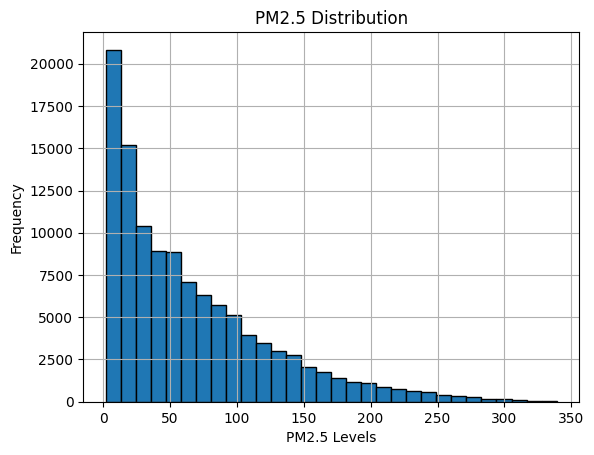

In [70]:
#The graph shows the frequency distribution of values.
merged_df['PM2.5'].hist(bins=30, edgecolor='black')
plt.title("PM2.5 Distribution")
plt.xlabel("PM2.5 Levels")
plt.ylabel("Frequency")
plt.show()

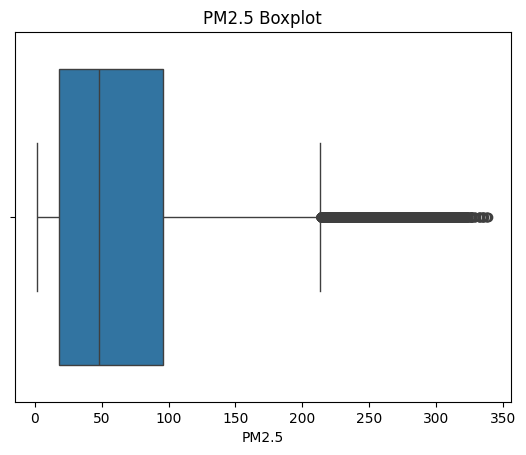

In [71]:
#Boxplot shows the outliers
sns.boxplot(x=merged_df['PM2.5'])
plt.title("PM2.5 Boxplot")
plt.show()

### PM10 Analysis:

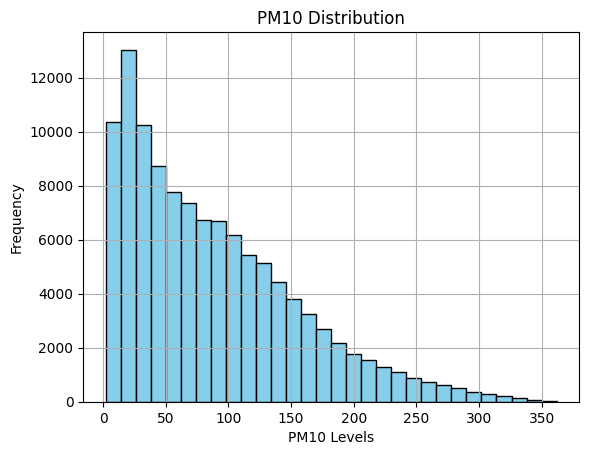

In [72]:
merged_df['PM10'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title("PM10 Distribution")
plt.xlabel("PM10 Levels")
plt.ylabel("Frequency")
plt.show()

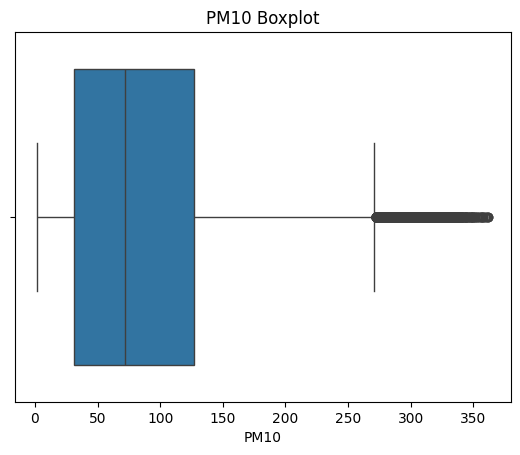

In [73]:
#Boxplot shows the outliers
sns.boxplot(x=merged_df['PM10'])
plt.title("PM10 Boxplot")
plt.show()

### SO2 Analysis:

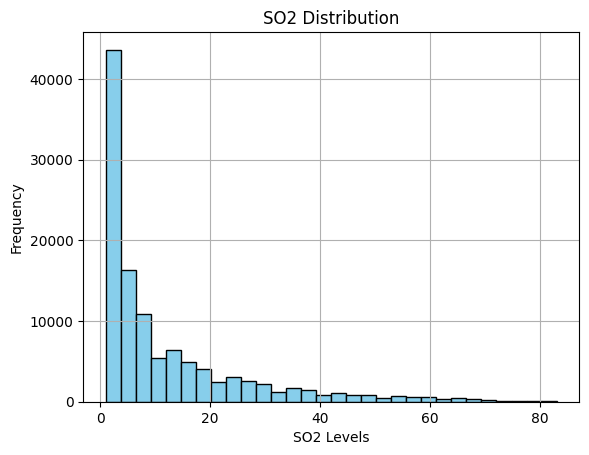

In [74]:
merged_df['SO2'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title("SO2 Distribution")
plt.xlabel("SO2 Levels")
plt.ylabel("Frequency")
plt.show()

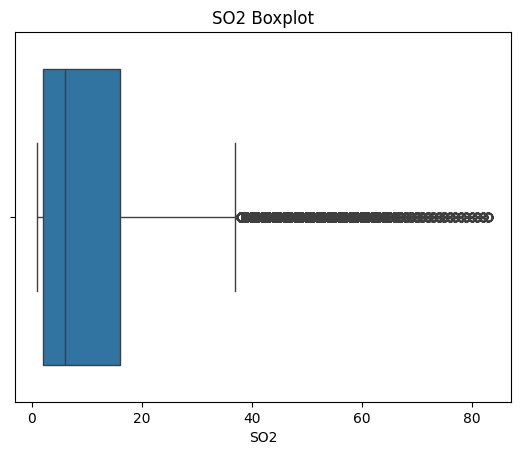

In [75]:
#Boxplot shows the outliers
sns.boxplot(x=merged_df['SO2'])
plt.title("SO2 Boxplot")
plt.show()

### NO2 Analysis:

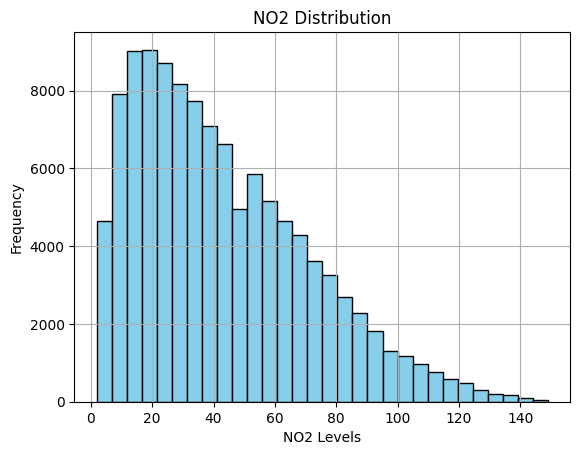

In [76]:
merged_df['NO2'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title("NO2 Distribution")
plt.xlabel("NO2 Levels")
plt.ylabel("Frequency")
plt.show()

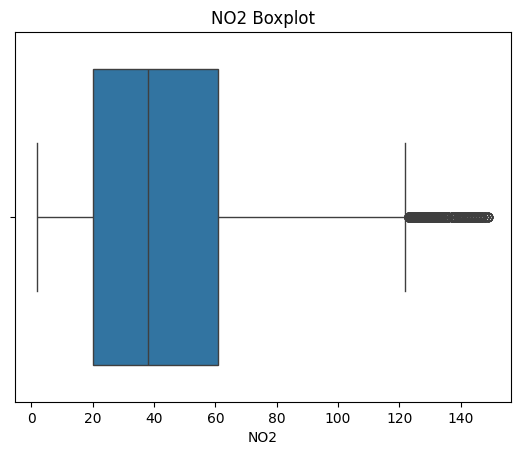

In [77]:
#Boxplot shows the outliers
sns.boxplot(x=merged_df['NO2'])
plt.title("NO2 Boxplot")
plt.show()

### CO Analysis:

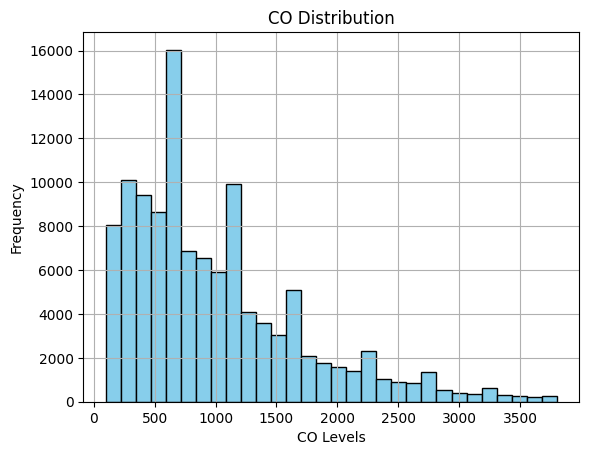

In [78]:
merged_df['CO'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title("CO Distribution")
plt.xlabel("CO Levels")
plt.ylabel("Frequency")
plt.show()

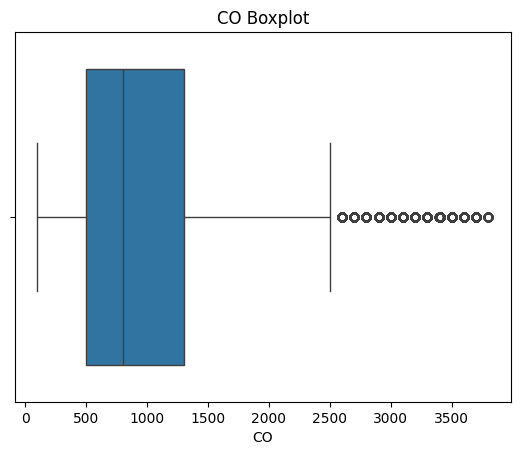

In [79]:
#Boxplot shows the outliers
sns.boxplot(x=merged_df['CO'])
plt.title("CO Boxplot")
plt.show()

### TEMP Analysis:

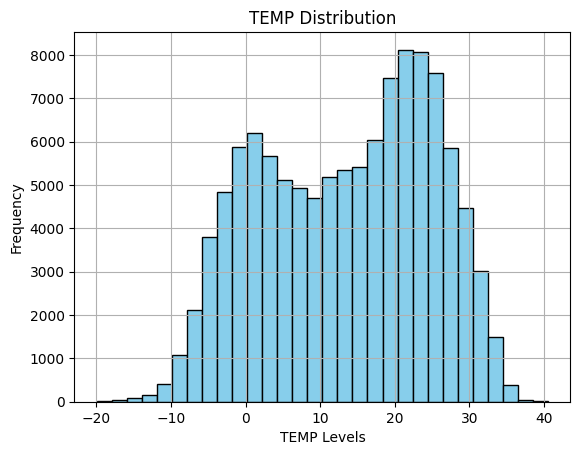

In [80]:
merged_df['TEMP'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title("TEMP Distribution")
plt.xlabel("TEMP Levels")
plt.ylabel("Frequency")
plt.show()

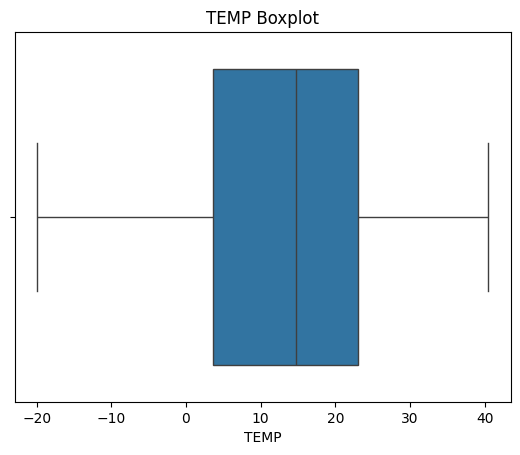

In [81]:
#Boxplot shows the outliers
sns.boxplot(x=merged_df['TEMP'])
plt.title("TEMP Boxplot")
plt.show()

### PRES Analysis:

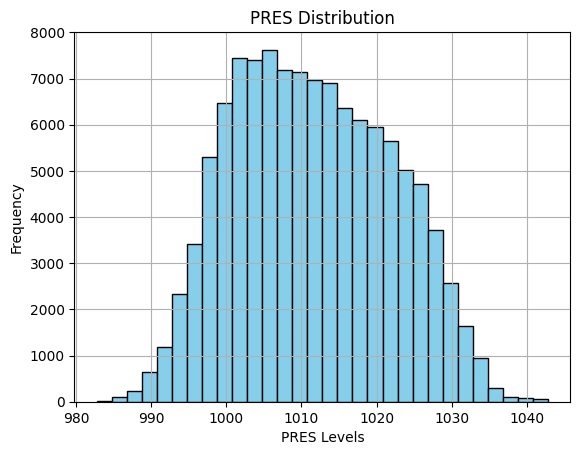

In [82]:
merged_df['PRES'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title("PRES Distribution")
plt.xlabel("PRES Levels")
plt.ylabel("Frequency")
plt.show()

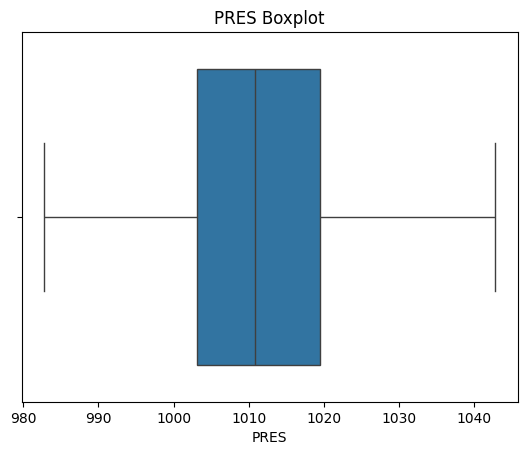

In [83]:
#Boxplot shows the outliers
sns.boxplot(x=merged_df['PRES'])
plt.title("PRES Boxplot")
plt.show()

### DEWP Analysis:

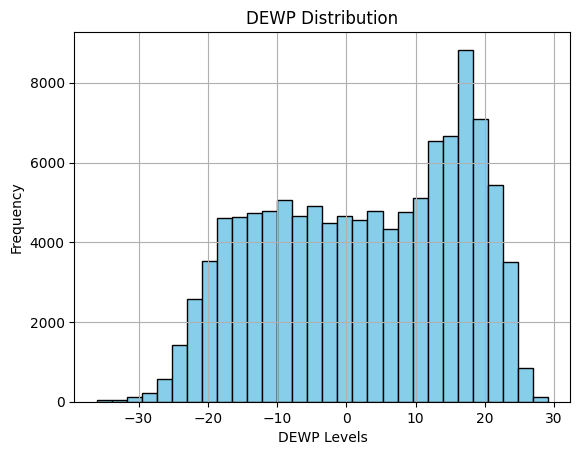

In [84]:
merged_df['DEWP'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title("DEWP Distribution")
plt.xlabel("DEWP Levels")
plt.ylabel("Frequency")
plt.show()

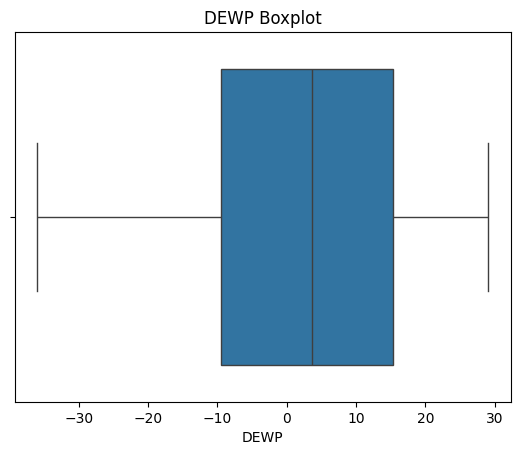

In [85]:
#Boxplot shows the outliers
sns.boxplot(x=merged_df['DEWP'])
plt.title("DEWP Boxplot")
plt.show()

### RAIN Analysis:

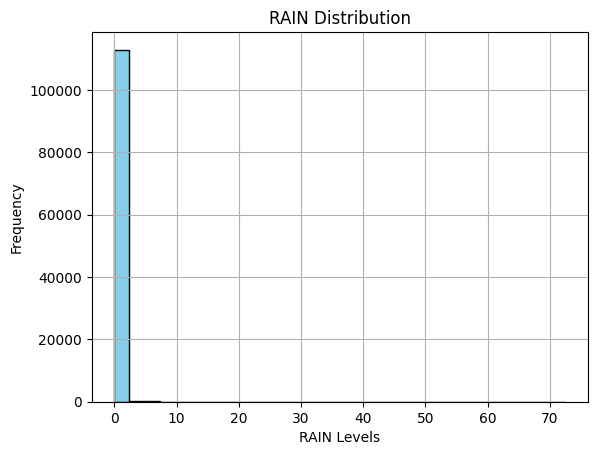

In [86]:
merged_df['RAIN'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title("RAIN Distribution")
plt.xlabel("RAIN Levels")
plt.ylabel("Frequency")
plt.show()

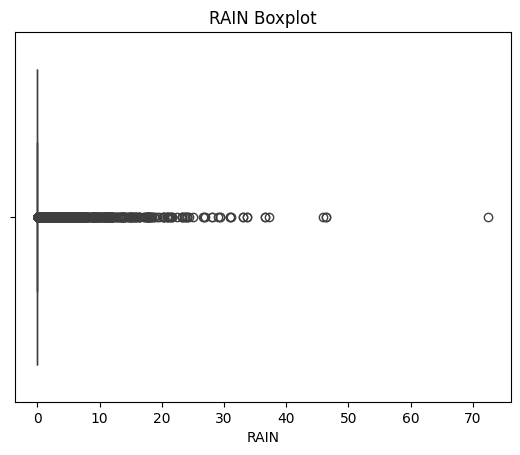

In [87]:
#Boxplot shows the outliers
sns.boxplot(x=merged_df['RAIN'])
plt.title("RAIN Boxplot")
plt.show()

### wd Analysis:

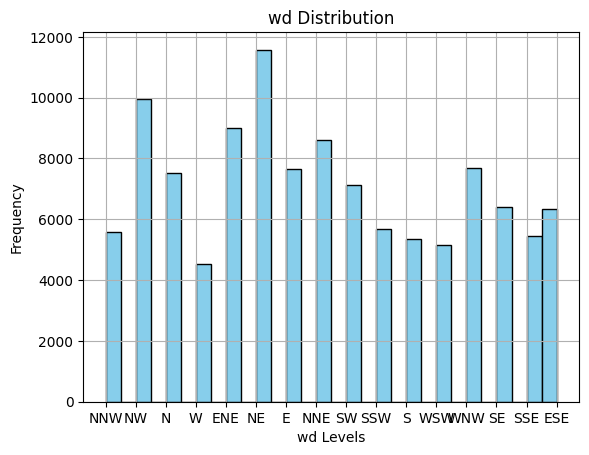

In [88]:
merged_df['wd'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title("wd Distribution")
plt.xlabel("wd Levels")
plt.ylabel("Frequency")
plt.show()

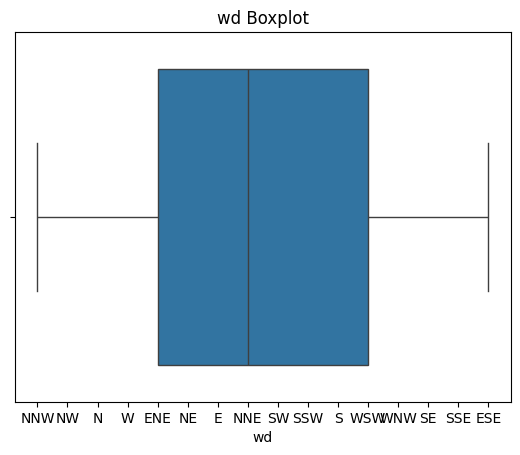

In [89]:
#Boxplot shows the outliers
sns.boxplot(x=merged_df['wd'])
plt.title("wd Boxplot")
plt.show()

### WSPM Analysis:

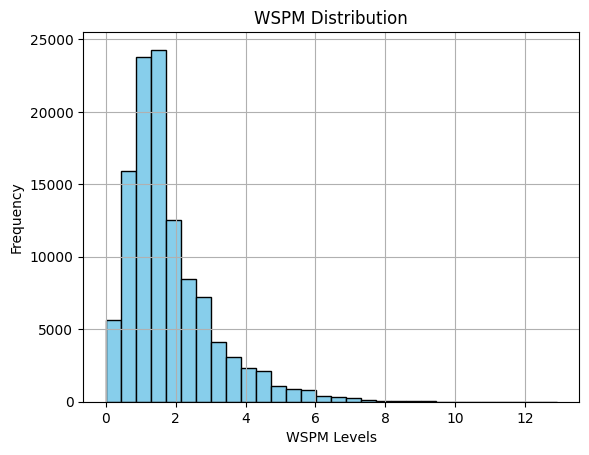

In [90]:
merged_df['WSPM'].hist(bins=30, color='skyblue', edgecolor='black')
plt.title("WSPM Distribution")
plt.xlabel("WSPM Levels")
plt.ylabel("Frequency")
plt.show()

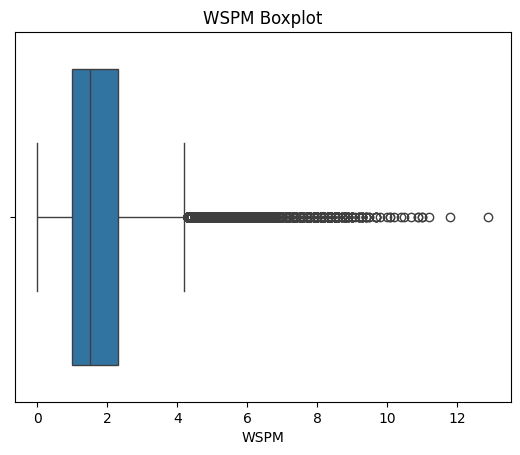

In [91]:
#Boxplot shows the outliers
sns.boxplot(x=merged_df['WSPM'])
plt.title("WSPM Boxplot")
plt.show()

### Distribution of Categorical Variables:

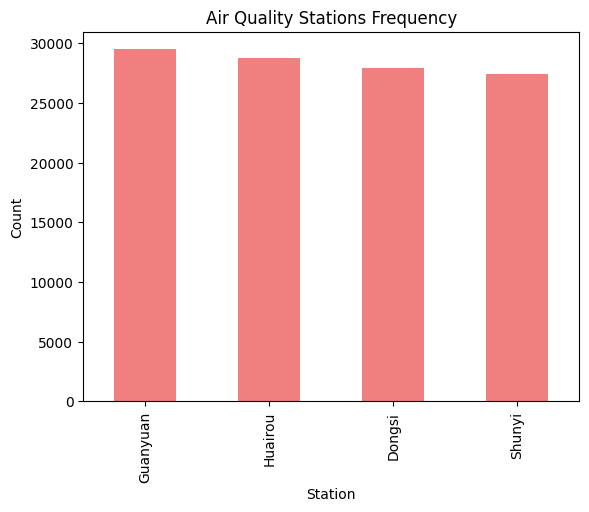

In [92]:
merged_df['station'].value_counts().plot(kind='bar', color='lightcoral')
plt.title("Air Quality Stations Frequency")
plt.xlabel("Station")
plt.ylabel("Count")
plt.show()

## Bivariate Analysis:

Bivariate Analysis analyzes the relationship between two variables.

### Pollutants vs Conditions:

Checking to see how pollutants react in various conditions.

 #### PM2.5 vs various conditions:

##### PM2.5 vs Temperature

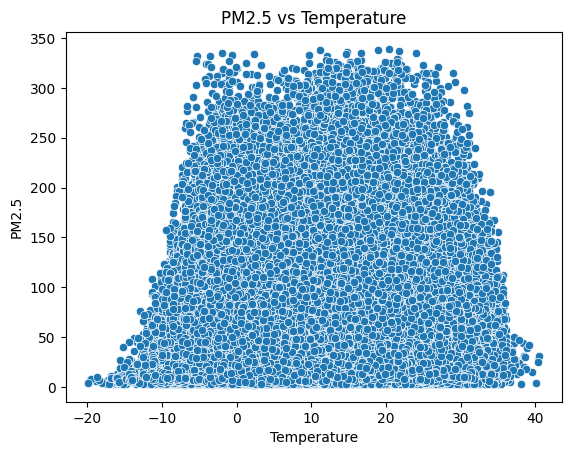

In [93]:
sns.scatterplot(x='TEMP', y='PM2.5', data=merged_df)
plt.title("PM2.5 vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("PM2.5")
plt.show()

##### PM2.5 vs Wind Speed:

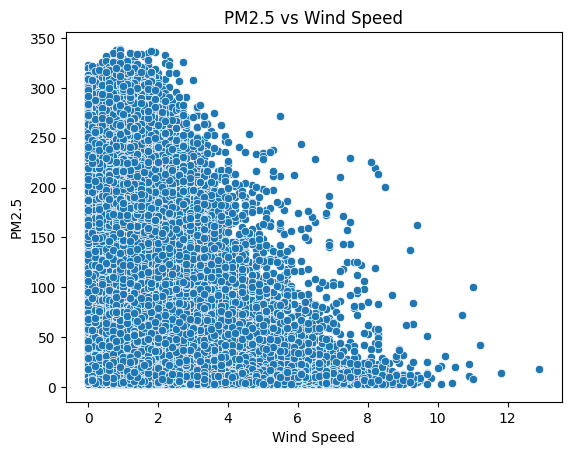

In [94]:
sns.scatterplot(x='WSPM', y='PM2.5', data=merged_df)
plt.title("PM2.5 vs Wind Speed")
plt.xlabel("Wind Speed")
plt.ylabel("PM2.5")
plt.show()

##### PM2.5 vs Rainfall

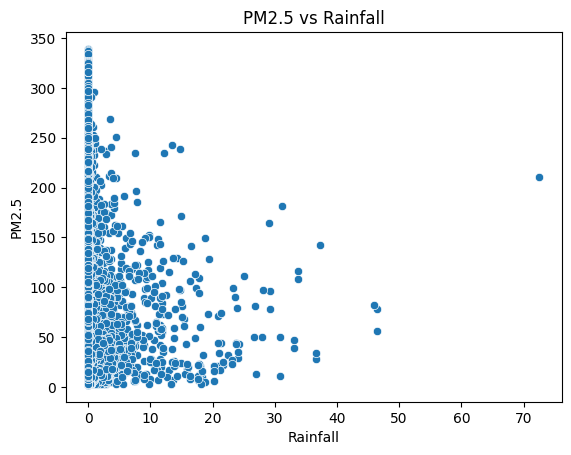

In [95]:
sns.scatterplot(x='RAIN', y='PM2.5', data=merged_df)
plt.title("PM2.5 vs Rainfall")
plt.xlabel("Rainfall")
plt.ylabel("PM2.5")
plt.show()

##### PM2.5 vs Humidity/Dew Point

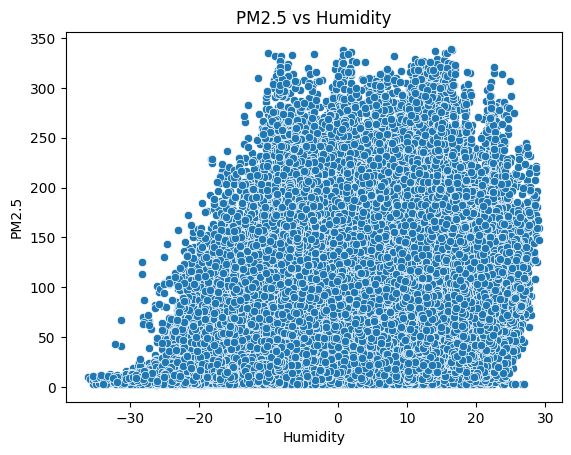

In [96]:
sns.scatterplot(x='DEWP', y='PM2.5', data=merged_df)
plt.title("PM2.5 vs Humidity")
plt.xlabel("Humidity")
plt.ylabel("PM2.5")
plt.show()

 #### PM10 vs various conditions:

##### PM10 vs Temperature

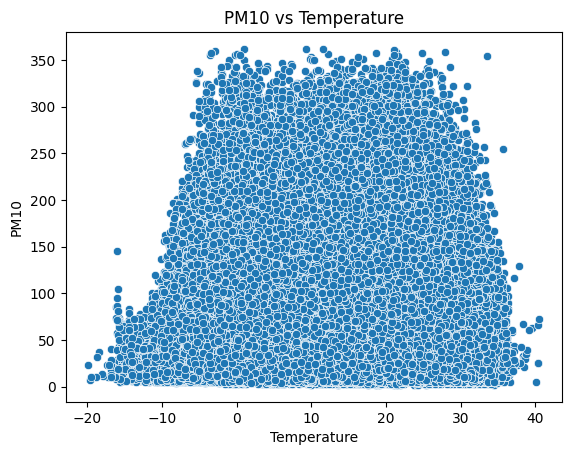

In [97]:
sns.scatterplot(x='TEMP', y='PM10', data=merged_df)
plt.title("PM10 vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("PM10")
plt.show()

##### PM10 vs Wind Speed:

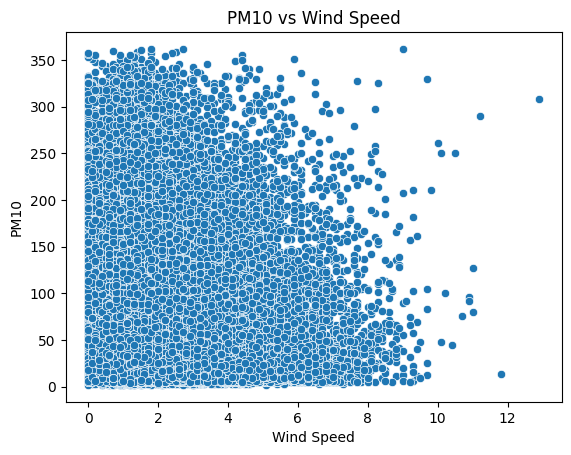

In [98]:
sns.scatterplot(x='WSPM', y='PM10', data=merged_df)
plt.title("PM10 vs Wind Speed")
plt.xlabel("Wind Speed")
plt.ylabel("PM10")
plt.show()

##### PM10 vs Rainfall

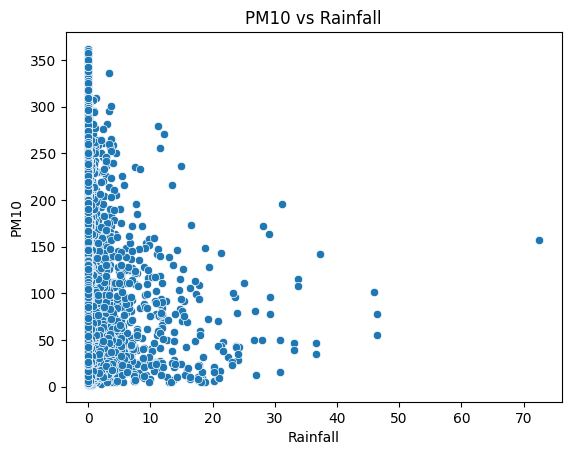

In [99]:
sns.scatterplot(x='RAIN', y='PM10', data=merged_df)
plt.title("PM10 vs Rainfall")
plt.xlabel("Rainfall")
plt.ylabel("PM10")
plt.show()

##### PM10 vs Humidity/Dew Point

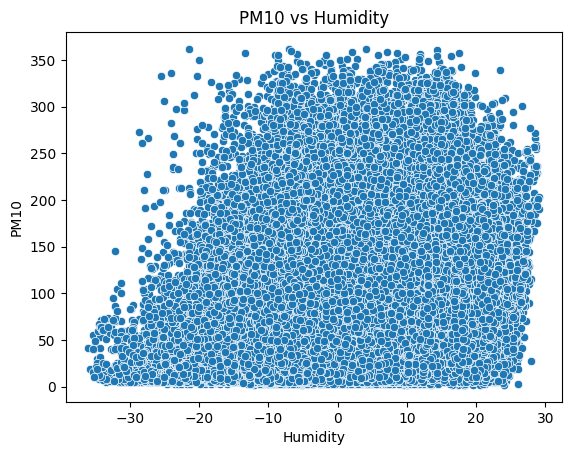

In [100]:
sns.scatterplot(x='DEWP', y='PM10', data=merged_df)
plt.title("PM10 vs Humidity")
plt.xlabel("Humidity")
plt.ylabel("PM10")
plt.show()

 #### SO2 vs various conditions:

##### SO2 vs Temperature

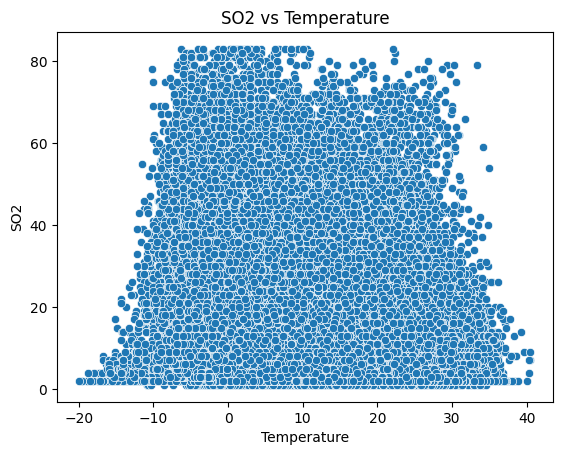

In [101]:
sns.scatterplot(x='TEMP', y='SO2', data=merged_df)
plt.title("SO2 vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("SO2")
plt.show()

##### SO2 vs Wind Speed:

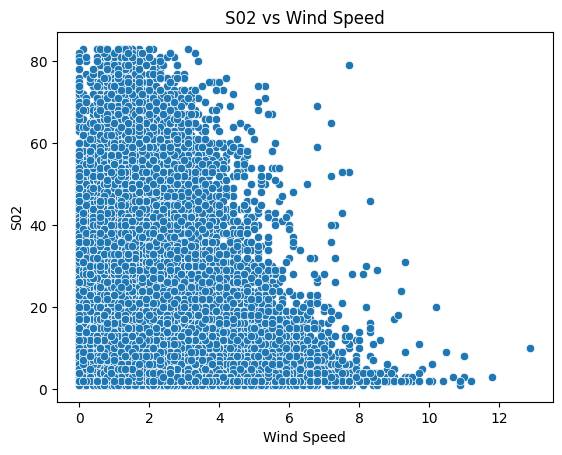

In [102]:
sns.scatterplot(x='WSPM', y='SO2', data=merged_df)
plt.title("S02 vs Wind Speed")
plt.xlabel("Wind Speed")
plt.ylabel("S02")
plt.show()

##### SO2 vs Rainfall

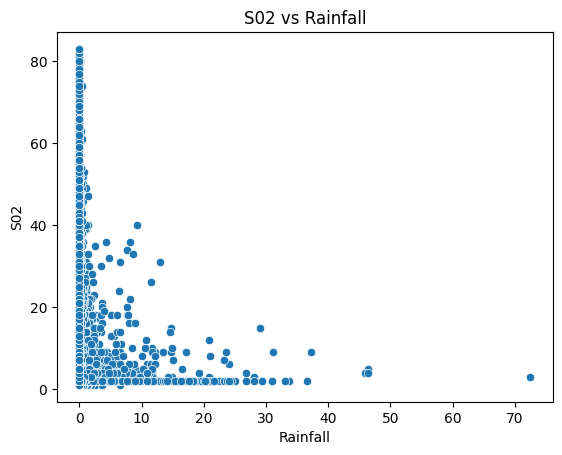

In [103]:
sns.scatterplot(x='RAIN', y='SO2', data=merged_df)
plt.title("S02 vs Rainfall")
plt.xlabel("Rainfall")
plt.ylabel("S02")
plt.show()

##### SO2 vs Humidity/Dew Point

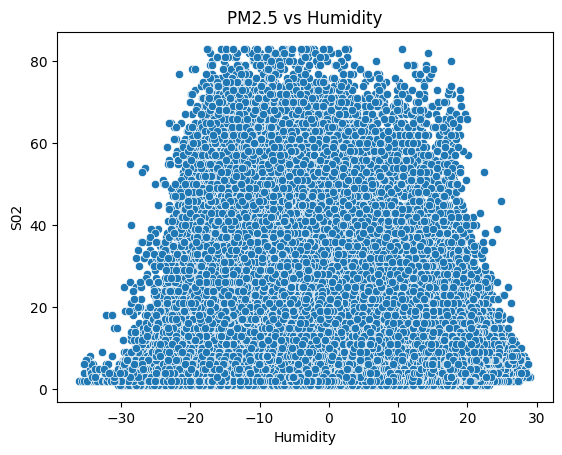

In [104]:
sns.scatterplot(x='DEWP', y='SO2', data=merged_df)
plt.title("PM2.5 vs Humidity")
plt.xlabel("Humidity")
plt.ylabel("S02")
plt.show()

 #### NO2 vs various conditions:

##### NO2 vs Temperature

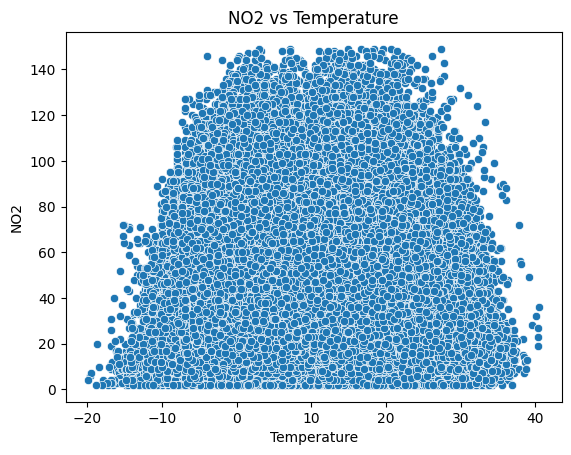

In [105]:
sns.scatterplot(x='TEMP', y='NO2', data=merged_df)
plt.title("NO2 vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("NO2")
plt.show()

##### N02 vs Wind Speed:

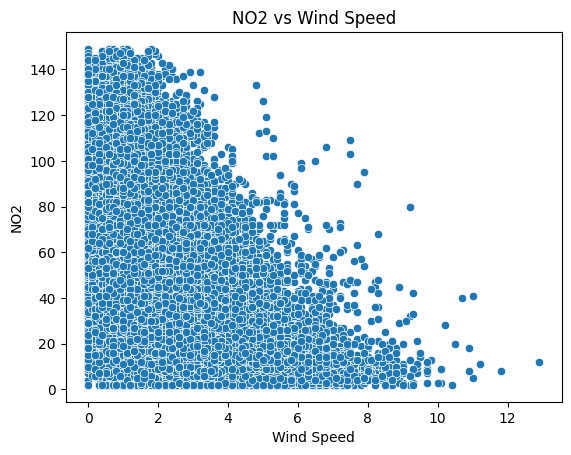

In [106]:
sns.scatterplot(x='WSPM', y='NO2', data=merged_df)
plt.title("NO2 vs Wind Speed")
plt.xlabel("Wind Speed")
plt.ylabel("NO2")
plt.show()

##### N02 vs Rainfall

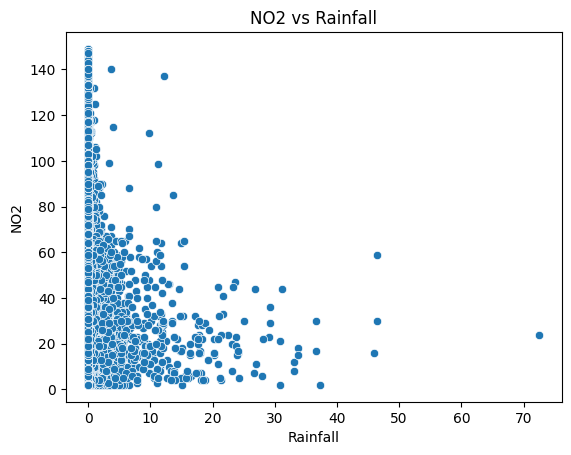

In [107]:
sns.scatterplot(x='RAIN', y='NO2', data=merged_df)
plt.title("NO2 vs Rainfall")
plt.xlabel("Rainfall")
plt.ylabel("NO2")
plt.show()

##### N02 vs Humidity/Dew Point

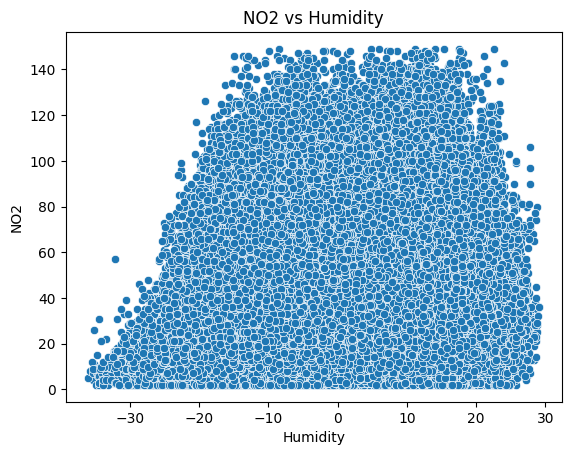

In [108]:
sns.scatterplot(x='DEWP', y='NO2', data=merged_df)
plt.title("NO2 vs Humidity")
plt.xlabel("Humidity")
plt.ylabel("NO2")
plt.show()

 #### CO vs various conditions:

##### CO vs Temperature

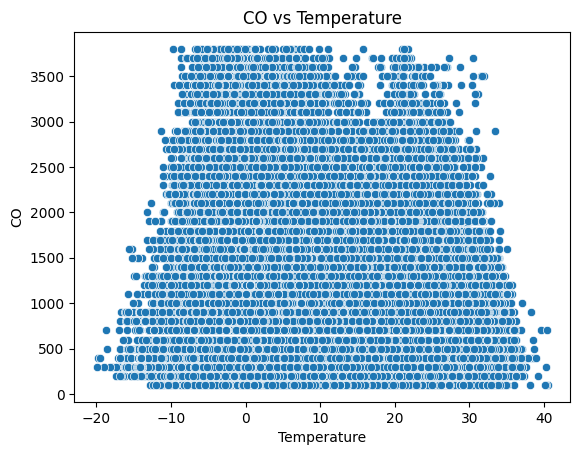

In [109]:
sns.scatterplot(x='TEMP', y='CO', data=merged_df)
plt.title("CO vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("CO")
plt.show()

##### CO vs Wind Speed:

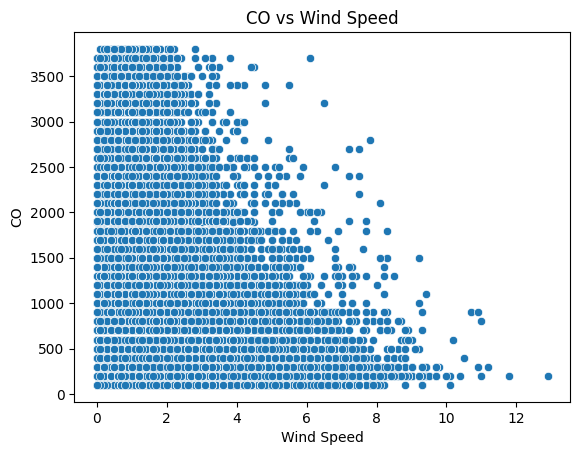

In [110]:
sns.scatterplot(x='WSPM', y='CO', data=merged_df)
plt.title("CO vs Wind Speed")
plt.xlabel("Wind Speed")
plt.ylabel("CO")
plt.show()

##### CO vs Rainfall

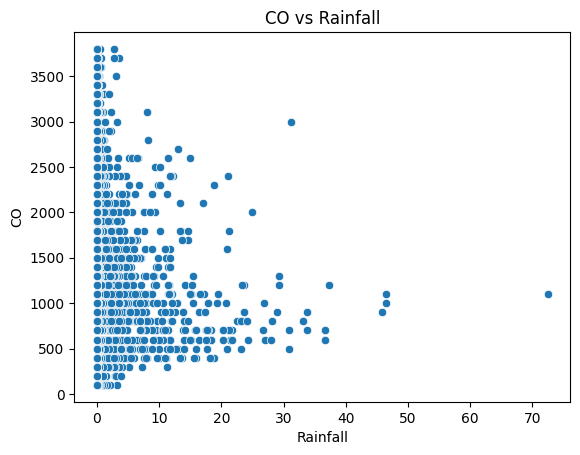

In [111]:
sns.scatterplot(x='RAIN', y='CO', data=merged_df)
plt.title("CO vs Rainfall")
plt.xlabel("Rainfall")
plt.ylabel("CO")
plt.show()

##### CO vs Humidity/Dew Point

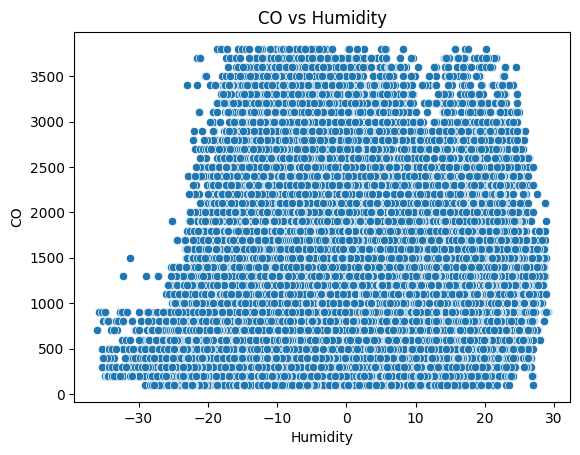

In [112]:
sns.scatterplot(x='DEWP', y='CO', data=merged_df)
plt.title("CO vs Humidity")
plt.xlabel("Humidity")
plt.ylabel("CO")
plt.show()

 #### O3 vs various conditions:

##### O3 vs Temperature

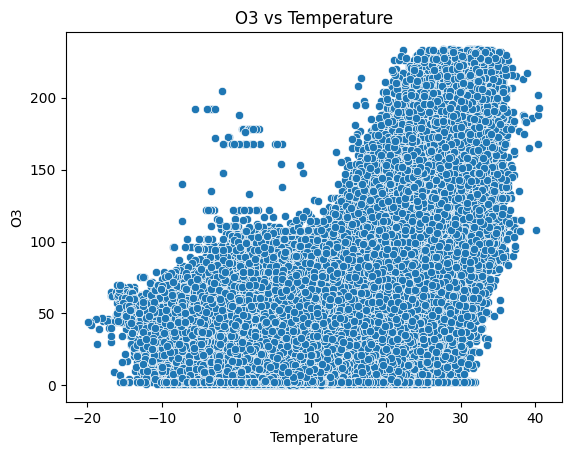

In [113]:
sns.scatterplot(x='TEMP', y='O3', data=merged_df)
plt.title("O3 vs Temperature")
plt.xlabel("Temperature")
plt.ylabel("O3")
plt.show()

##### O3 vs Wind Speed:

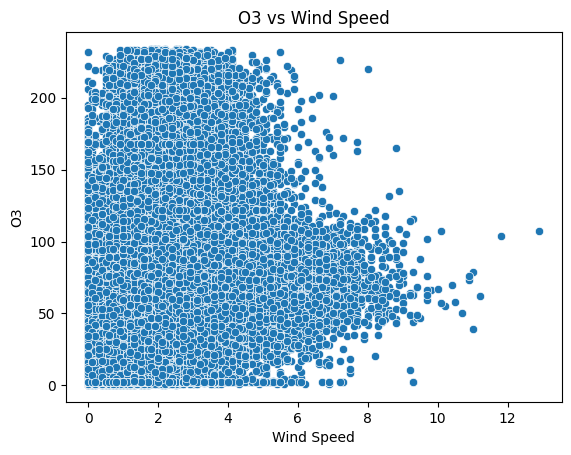

In [114]:
sns.scatterplot(x='WSPM', y='O3', data=merged_df)
plt.title("O3 vs Wind Speed")
plt.xlabel("Wind Speed")
plt.ylabel("O3")
plt.show()

##### O3 vs Rainfall

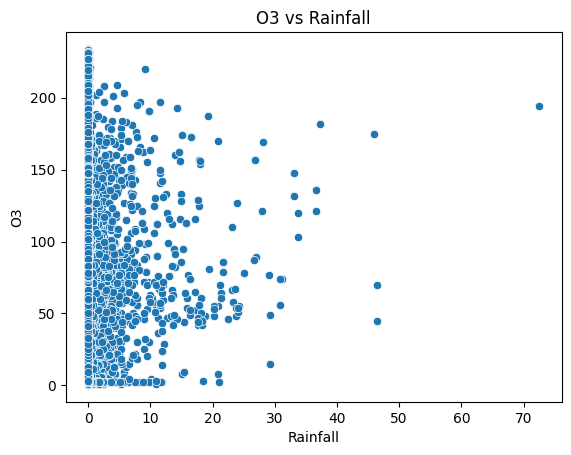

In [115]:
sns.scatterplot(x='RAIN', y='O3', data=merged_df)
plt.title("O3 vs Rainfall")
plt.xlabel("Rainfall")
plt.ylabel("O3")
plt.show()

##### O3 vs Humidity/Dew Point

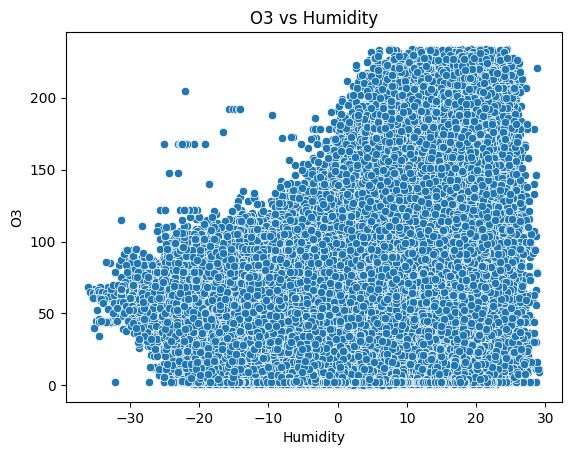

In [116]:
sns.scatterplot(x='DEWP', y='O3', data=merged_df)
plt.title("O3 vs Humidity")
plt.xlabel("Humidity")
plt.ylabel("O3")
plt.show()

## Multivariable Analysis:

Multivariate analysis is based in observation and analysis of more than one statistical outcome variable at a time

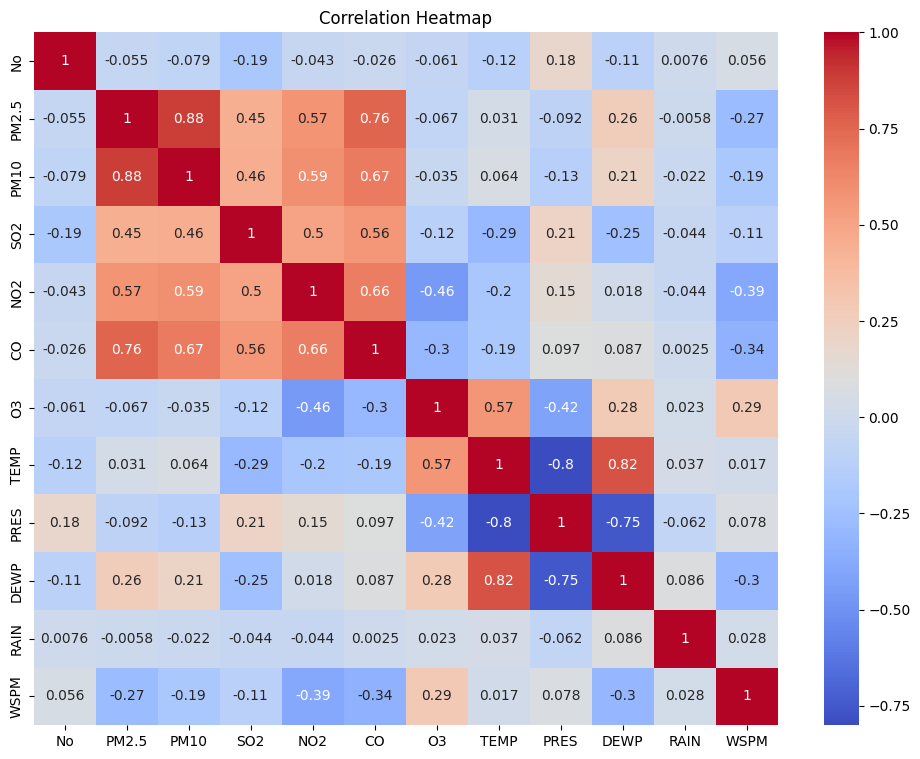

In [117]:
numeric_df = merged_df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(12, 9))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Time series Analysis:

Time series analysis is used fordata that is constantly fluctuating over time or is affected by time

###PM2.5 Over the years:

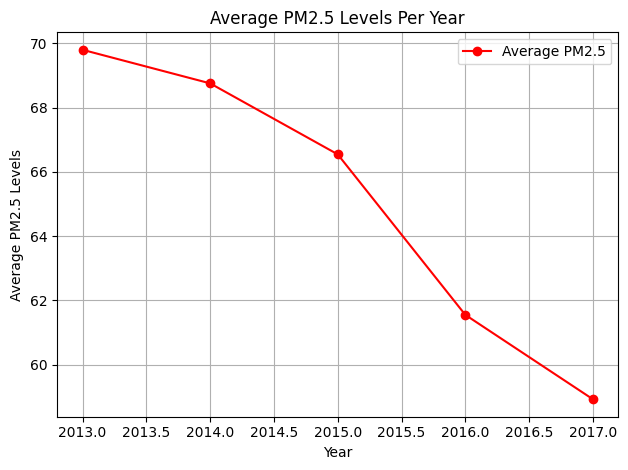

In [118]:
merged_df['year'] = merged_df['datetime'].dt.year
yearly_avg = merged_df.groupby('year')['PM2.5'].mean().reset_index()

plt.plot(yearly_avg['year'], yearly_avg['PM2.5'], marker='o', color='red', label='Average PM2.5')
plt.xlabel('Year')
plt.ylabel('Average PM2.5 Levels')
plt.title('Average PM2.5 Levels Per Year')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

###PM10 Over the years:

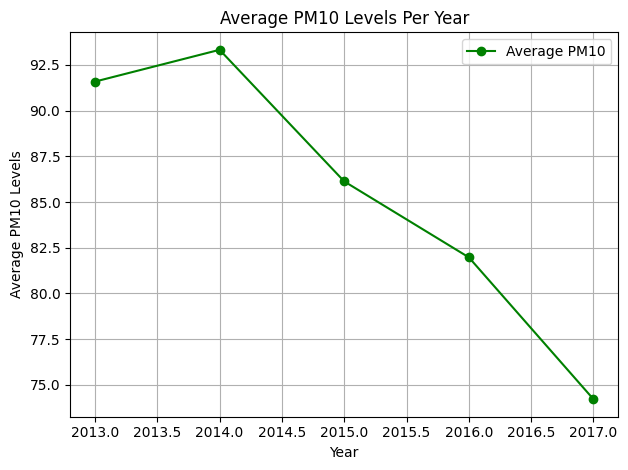

In [119]:
merged_df['year'] = merged_df['datetime'].dt.year
yearly_avg = merged_df.groupby('year')['PM10'].mean().reset_index()

plt.plot(yearly_avg['year'], yearly_avg['PM10'], marker='o', color='green', label='Average PM10')
plt.xlabel('Year')
plt.ylabel('Average PM10 Levels')
plt.title('Average PM10 Levels Per Year')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

###SO2 Over the years:

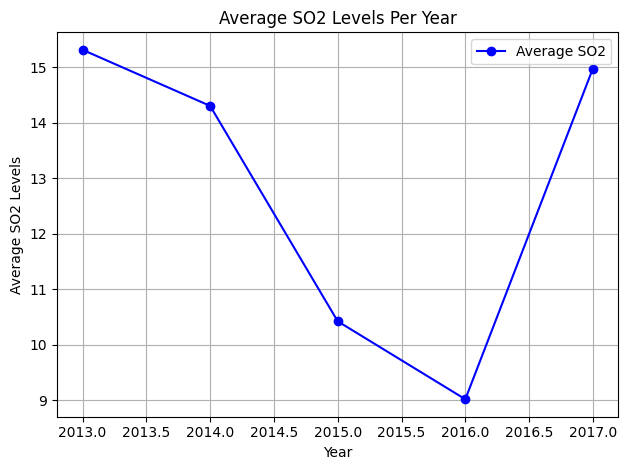

In [120]:
merged_df['year'] = merged_df['datetime'].dt.year
yearly_avg = merged_df.groupby('year')['SO2'].mean().reset_index()

plt.plot(yearly_avg['year'], yearly_avg['SO2'], marker='o', color='blue', label='Average SO2')
plt.xlabel('Year')
plt.ylabel('Average SO2 Levels')
plt.title('Average SO2 Levels Per Year')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

###NO2 Over the years:

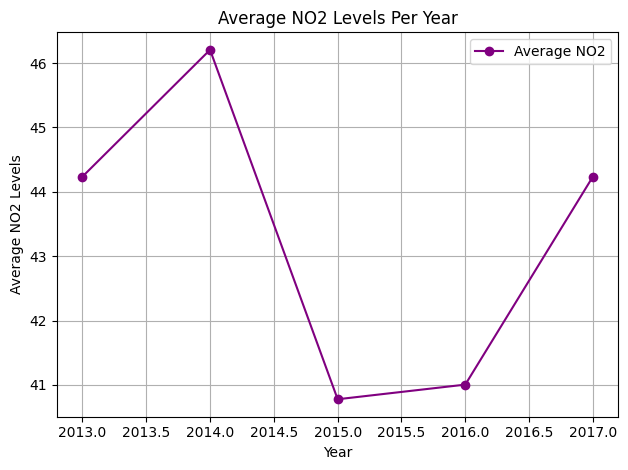

In [121]:
merged_df['year'] = merged_df['datetime'].dt.year
yearly_avg = merged_df.groupby('year')['NO2'].mean().reset_index()

plt.plot(yearly_avg['year'], yearly_avg['NO2'], marker='o', color='purple', label='Average NO2')
plt.xlabel('Year')
plt.ylabel('Average NO2 Levels')
plt.title('Average NO2 Levels Per Year')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

###CO Over the years:

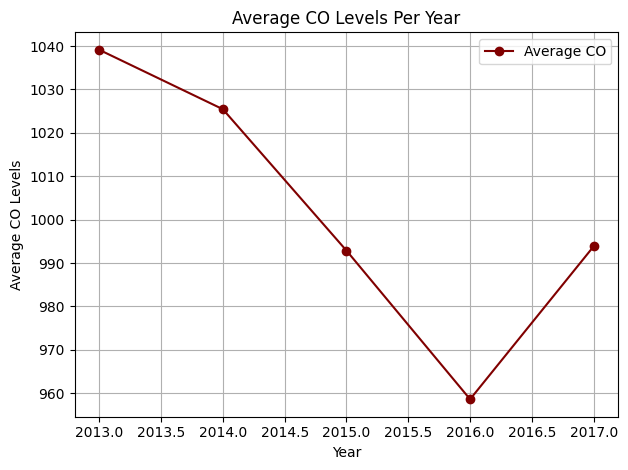

In [122]:
merged_df['year'] = merged_df['datetime'].dt.year
yearly_avg = merged_df.groupby('year')['CO'].mean().reset_index()

plt.plot(yearly_avg['year'], yearly_avg['CO'], marker='o', color='maroon', label='Average CO')
plt.xlabel('Year')
plt.ylabel('Average CO Levels')
plt.title('Average CO Levels Per Year')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

###O3 Over the years:

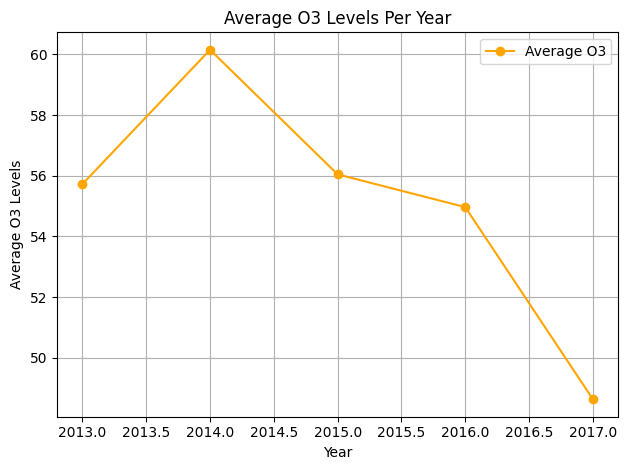

In [123]:
merged_df['year'] = merged_df['datetime'].dt.year
yearly_avg = merged_df.groupby('year')['O3'].mean().reset_index()

plt.plot(yearly_avg['year'], yearly_avg['O3'], marker='o', color='orange', label='Average O3')
plt.xlabel('Year')
plt.ylabel('Average O3 Levels')
plt.title('Average O3 Levels Per Year')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Feature Engineering:

### Polution Ratio:

These ratios help you understand the composition of the pollution.

#### PM Ratio:

 (Zhang and Cao, 2015) found that PM2.5 levels vary significantly across cities in China.

A high PM2.5/PM10 ratio = finer particles dominate, which are more harmful.

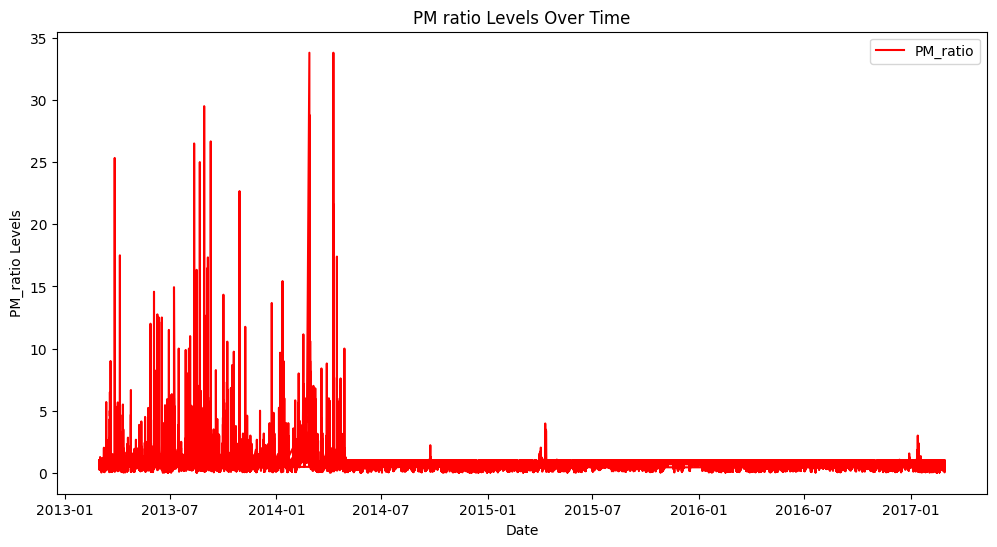

In [124]:
merged_df['PM_ratio'] = merged_df['PM2.5'] / merged_df['PM10']

plt.figure(figsize=(12, 6))
plt.plot(merged_df['datetime'], merged_df['PM_ratio'], label='PM_ratio', color='red')
plt.xlabel('Date')
plt.ylabel('PM_ratio Levels')
plt.title('PM ratio Levels Over Time')
plt.legend()
plt.show()

#### SO Ratio:

The ratio of sulfur dioxide to nitrogen oxides (SO = SO2/NO2) is one indicator of air pollution sources. (Nirel, Ronit. 2001)

SO2/NO2 might indicate vehicle vs industry pollution sources.

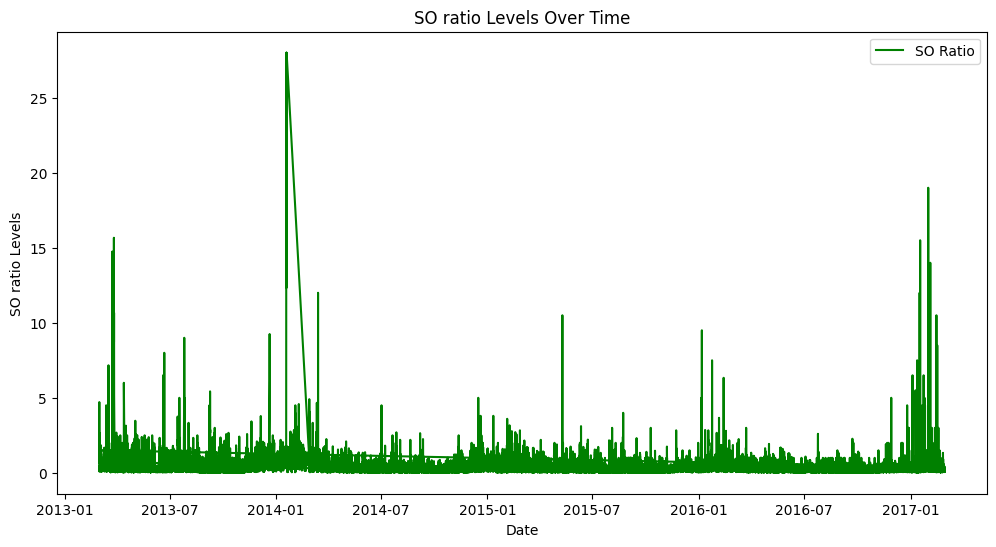

In [125]:
merged_df['SO_ratio'] = merged_df['SO2'] / merged_df['NO2']


plt.figure(figsize=(12, 6))
plt.plot(merged_df['datetime'], merged_df['SO_ratio'], label='SO Ratio', color='green')
plt.xlabel('Date')
plt.ylabel('SO ratio Levels')
plt.title('SO ratio Levels Over Time')
plt.legend()
plt.show()

### Rolling Averages:

It highlights the underlying trends and helps for forecasting models.

In [126]:
# Only using pm2.5 because its our main target
merged_df['pm25_3hr_avg'] = merged_df['PM2.5'].rolling(window=3).mean()

### Creating categories for Air Quality Index(AQI)

Air Quality Index(AQI) is used to measure the pollution at a certain location

#### PM2.5 AQI

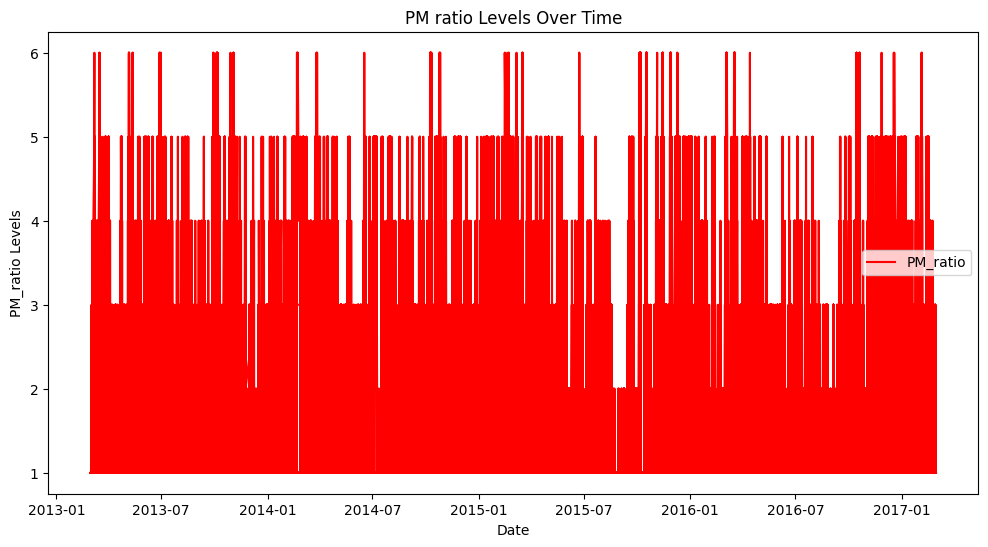

In [127]:
#1= 'Good', 2= 'Moderate', 3= 'Unhealthy', 4= 'Bad', 5= 'Very Unhealthy', 6= 'Hazardious', 7= 'Extremeley Hazardious
merged_df['PM25_AQI_level'] = pd.cut(merged_df['PM2.5'], bins=[0, 50, 100, 150, 200, 300, 500, 9999], labels=['1', '2', '3', '4', '5', '6', '7'])
# Dropping Null values
merged_df = merged_df.dropna(subset=['PM25_AQI_level'])
merged_df['PM25_AQI_level'] = merged_df['PM25_AQI_level'].astype(int)
merged_df['PM25_AQI_level']

plt.figure(figsize=(12, 6))
plt.plot(merged_df['datetime'], merged_df['PM25_AQI_level'], label='PM_ratio', color='red')
plt.xlabel('Date')
plt.ylabel('PM_ratio Levels')
plt.title('PM ratio Levels Over Time')
plt.legend()
plt.show()

#### PM10 AQI

In [128]:
#1= 'Good', 2= 'Moderate', 3= 'Unhealthy', 4= 'Bad', 5= 'Very Unhealthy', 6= 'Hazardious', 7= 'Extremeley Hazardious
merged_df['PM10_AQI_level'] = pd.cut(merged_df['PM10'], bins=[0, 50, 100, 150, 200, 300, 500, 9999], labels=['1', '2', '3', '4', '5', '6', '7'])
# Dropping Null values
merged_df = merged_df.dropna(subset=['PM10_AQI_level'])
merged_df['PM10_AQI_level'] = merged_df['PM10_AQI_level'].astype(int)
merged_df['PM10_AQI_level']

,PM10_AQI_level
0,1
1,1
2,1
3,1
4,1
...,...
113562,1
113563,1
113564,1
113565,1


#### SO2 AQI

In [129]:
#1= 'Good', 2= 'Moderate', 3= 'Unhealthy', 4= 'Bad', 5= 'Very Unhealthy', 6= 'Hazardious', 7= 'Extremeley Hazardious
merged_df['SO2_AQI_level'] = pd.cut(merged_df['SO2'], bins=[0, 50, 100, 150, 200, 300, 500, 9999], labels=['1', '2', '3', '4', '5', '6', '7'])
# Dropping Null values
merged_df = merged_df.dropna(subset=['SO2_AQI_level'])
merged_df['SO2_AQI_level'] = merged_df['SO2_AQI_level'].astype(int)
merged_df['SO2_AQI_level']

,SO2_AQI_level
0,1
1,1
2,1
3,1
4,1
...,...
113562,1
113563,1
113564,1
113565,1


#### NO2 AQI

In [130]:
#1= 'Good', 2= 'Moderate', 3= 'Unhealthy', 4= 'Bad', 5= 'Very Unhealthy', 6= 'Hazardious', 7= 'Extremeley Hazardious
merged_df['NO2_AQI_level'] = pd.cut(merged_df['NO2'], bins=[0, 50, 100, 150, 200, 300, 500, 9999], labels=['1', '2', '3', '4', '5', '6', '7'])
# Dropping Null values
merged_df = merged_df.dropna(subset=['NO2_AQI_level'])
merged_df['NO2_AQI_level'] = merged_df['NO2_AQI_level'].astype(int)
merged_df['NO2_AQI_level']

,NO2_AQI_level
0,1
1,1
2,1
3,1
4,1
...,...
113562,1
113563,1
113564,1
113565,1


#### CO AQI

In [131]:
#1= 'Good', 2= 'Moderate', 3= 'Unhealthy', 4= 'Bad', 5= 'Very Unhealthy', 6= 'Hazardious', 7= 'Extremeley Hazardious
merged_df['CO_AQI_level'] = pd.cut(merged_df['CO'], bins=[0, 50, 100, 150, 200, 300, 600, 9999], labels=['1', '2', '3', '4', '5', '6', '7'])
# Dropping Null values
merged_df = merged_df.dropna(subset=['CO_AQI_level'])
merged_df['CO_AQI_level'] = merged_df['CO_AQI_level'].astype(int)
merged_df['CO_AQI_level']

,CO_AQI_level
0,5
1,5
2,5
3,6
4,6
...,...
113562,6
113563,6
113564,6
113565,6


#### O3 AQI

In [132]:
#1= 'Good', 2= 'Moderate', 3= 'Unhealthy', 4= 'Bad', 5= 'Very Unhealthy', 6= 'Hazardious', 7= 'Extremeley Hazardious
merged_df['O3_AQI_level'] = pd.cut(merged_df['NO2'], bins=[0, 50, 100, 150, 200, 300, 500, 9999], labels=['1', '2', '3', '4', '5', '6', '7'])
# Dropping Null values
merged_df = merged_df.dropna(subset=['O3_AQI_level'])
merged_df['O3_AQI_level'] = merged_df['O3_AQI_level'].astype(int)
merged_df['O3_AQI_level']

,O3_AQI_level
0,1
1,1
2,1
3,1
4,1
...,...
113562,1
113563,1
113564,1
113565,1


#### Dealing with missing values:

In [133]:
merged_df.isnull().sum()

,0
datetime,0
No,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0
O3,0
TEMP,0
PRES,0


In [134]:
merged_df.dropna(inplace=True)
merged_df.isnull().sum() # To check if there are any missing values left

,0
datetime,0
No,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0
O3,0
TEMP,0
PRES,0


### Turning string into numerical data:

add one hot encoding or label encoding

Only numerical data can be used to train ML models.

In [135]:
# One-hot encode wind direction
wd_dummies = pd.get_dummies(merged_df['wd'], prefix='wd')

# Concatenate with original dataframe
merged_df = pd.concat([merged_df.drop('wd', axis=1), wd_dummies], axis=1)
merged_df

,datetime,No,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,...,wd_NNW,wd_NW,wd_S,wd_SE,wd_SSE,wd_SSW,wd_SW,wd_W,wd_WNW,wd_WSW
2,2013-03-01 05:00:00,6,4.0,4.0,9.0,25.0,300.0,78.0,-2.4,1027.5,...,False,True,False,False,False,False,False,False,False,False
3,2013-03-01 06:00:00,7,5.0,5.0,10.0,29.0,400.0,67.0,-2.5,1028.2,...,False,True,False,False,False,False,False,False,False,False
4,2013-03-01 07:00:00,8,3.0,6.0,12.0,40.0,400.0,52.0,-1.4,1029.5,...,True,False,False,False,False,False,False,False,False,False
5,2013-03-01 08:00:00,9,3.0,6.0,12.0,41.0,500.0,54.0,-0.3,1030.4,...,False,True,False,False,False,False,False,False,False,False
6,2013-03-01 09:00:00,10,3.0,6.0,9.0,31.0,400.0,69.0,0.4,1030.5,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113562,2017-02-28 19:00:00,35060,13.0,37.0,3.0,36.0,400.0,60.0,12.5,1013.5,...,False,True,False,False,False,False,False,False,False,False
113563,2017-02-28 20:00:00,35061,20.0,43.0,4.0,48.0,500.0,43.0,11.6,1013.6,...,False,False,False,False,False,False,False,False,True,False
113564,2017-02-28 21:00:00,35062,16.0,33.0,5.0,39.0,500.0,50.0,10.8,1014.2,...,False,True,False,False,False,False,False,False,False,False
113565,2017-02-28 22:00:00,35063,11.0,24.0,5.0,47.0,500.0,41.0,10.5,1014.4,...,True,False,False,False,False,False,False,False,False,False


### Station Data:

Pollution varies by location type, so it is important to add meta data.

In [136]:
merged_df['station'] = merged_df['station'].map({'Dongsi': 'Urban', 'Shunyi': 'Suburban', 'Huairou': 'Rural', 'Guanyuan': 'Industrial', })


### Average of Pollutants by station:

#### Average PM2.5 by Station:

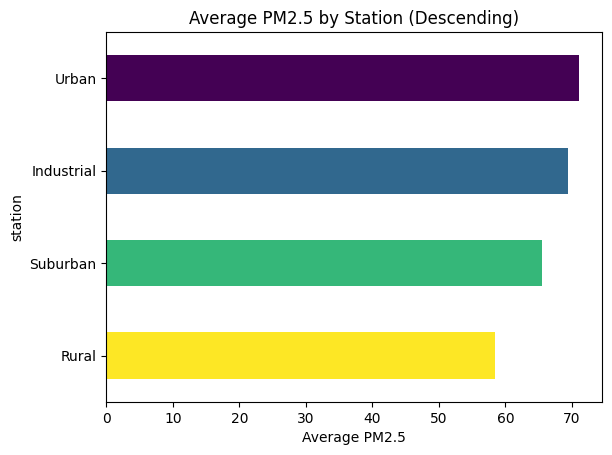

In [137]:
# Group, sort, and plot with colormap
pm25_means = merged_df.groupby('station')['PM2.5'].mean().sort_values(ascending=False)
pm25_means.plot(kind='barh', color=plt.cm.viridis(np.linspace(0, 1, len(pm25_means))))

plt.xlabel('Average PM2.5')
plt.title("Average PM2.5 by Station (Descending)")
plt.gca().invert_yaxis()  # So highest is on top
plt.show()

#### Average PM10 by Station:

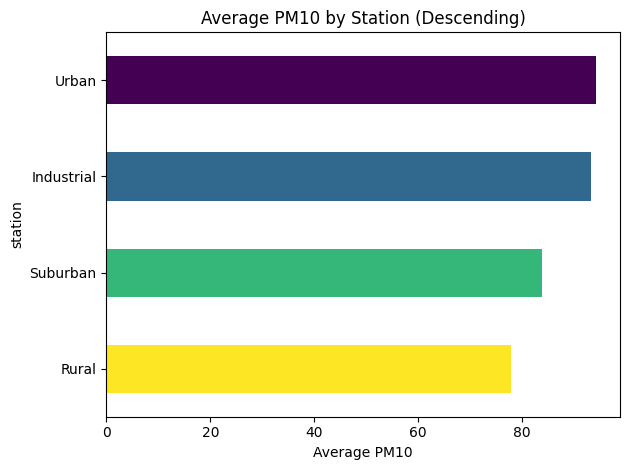

In [138]:
# Group, sort, and plot with colormap
pm25_means = merged_df.groupby('station')['PM10'].mean().sort_values(ascending=False)
pm25_means.plot(kind='barh', color=plt.cm.viridis(np.linspace(0, 1, len(pm25_means))))

plt.xlabel('Average PM10')
plt.title("Average PM10 by Station (Descending)")
plt.gca().invert_yaxis()  # So highest is on top
plt.tight_layout()
plt.show()

#### Average SO2 by Station:

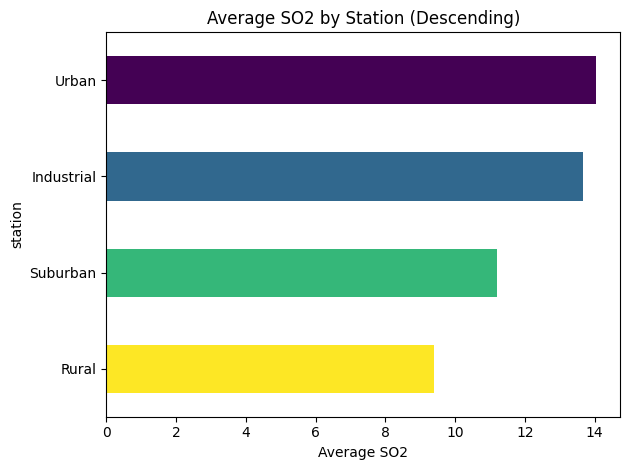

In [139]:
# Group, sort, and plot with colormap
pm25_means = merged_df.groupby('station')['SO2'].mean().sort_values(ascending=False)
pm25_means.plot(kind='barh', color=plt.cm.viridis(np.linspace(0, 1, len(pm25_means))))

plt.xlabel('Average SO2')
plt.title("Average SO2 by Station (Descending)")
plt.gca().invert_yaxis()  # So highest is on top
plt.tight_layout()
plt.show()

#### Average NO2 by Station:

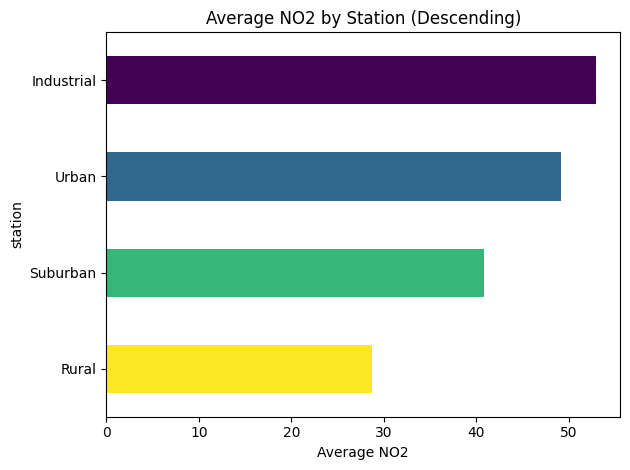

In [140]:
# Group, sort, and plot with colormap
pm25_means = merged_df.groupby('station')['NO2'].mean().sort_values(ascending=False)
pm25_means.plot(kind='barh', color=plt.cm.viridis(np.linspace(0, 1, len(pm25_means))))

plt.xlabel('Average NO2')
plt.title("Average NO2 by Station (Descending)")
plt.gca().invert_yaxis()  # So highest is on top
plt.tight_layout()
plt.show()

#### Average CO by Station:

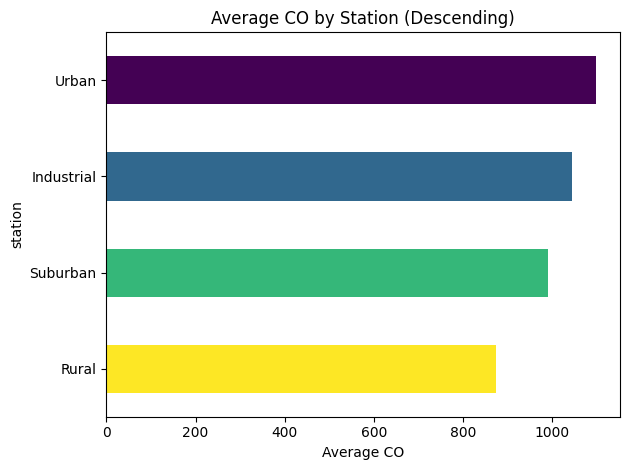

In [141]:
# Group, sort, and plot with colormap
pm25_means = merged_df.groupby('station')['CO'].mean().sort_values(ascending=False)
pm25_means.plot(kind='barh', color=plt.cm.viridis(np.linspace(0, 1, len(pm25_means))))

plt.xlabel('Average CO')
plt.title("Average CO by Station (Descending)")
plt.gca().invert_yaxis()  # So highest is on top
plt.tight_layout()
plt.show()

#### Average O3 by Station:

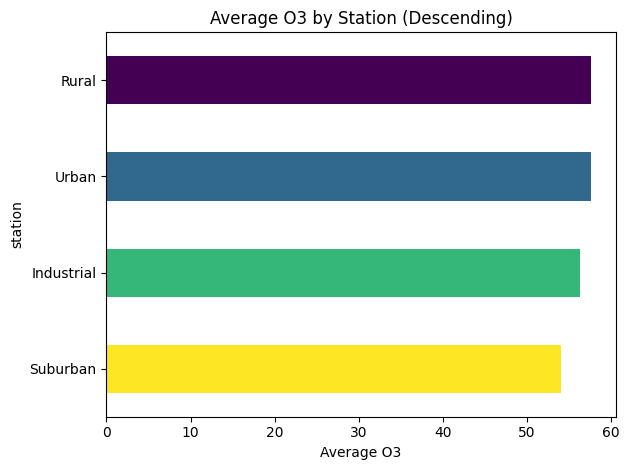

In [142]:
# Group, sort, and plot with colormap
pm25_means = merged_df.groupby('station')['O3'].mean().sort_values(ascending=False)
pm25_means.plot(kind='barh', color=plt.cm.viridis(np.linspace(0, 1, len(pm25_means))))

plt.xlabel('Average O3')
plt.title("Average O3 by Station (Descending)")
plt.gca().invert_yaxis()  # So highest is on top
plt.tight_layout()
plt.show()

### Cleaned and Transformed Dataset:

In [143]:
merged_df.to_csv('Transformed_dataset.csv', index=False)

###Scaling Data:

In [144]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load your dataset
merged_df = pd.read_csv('Transformed_dataset.csv')

# Convert 'station' from string to numeric
merged_df['station'] = merged_df['station'].map({
    'Urban': 1,
    'Suburban': 2,
    'Rural': 3,
    'Industrial': 4
})

# Drop datetime before scaling
merged_df_no_dt = merged_df.drop(columns=['datetime'])

# Apply MinMaxScaler
scaler = MinMaxScaler()
scaled_array = scaler.fit_transform(merged_df_no_dt)

# Recreate DataFrame
scaled_df = pd.DataFrame(scaled_array, columns=merged_df_no_dt.columns)

# Optional: Add datetime back
scaled_df['datetime'] = merged_df['datetime']

# Save final dataset
scaled_df.to_csv('Final_Scaled_Dataset.csv', index=False)


# **Model building:**

### Splitting Data:

Data is Split into Features (X) and Labels (y)

In [145]:
# This seperates our target on one side () and the rest of the data on the other (y)
X = scaled_df.drop('PM2.5', axis=1)
y = scaled_df['PM2.5']

In [146]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### PM2.5 Distribution Plot (Train vs Test):

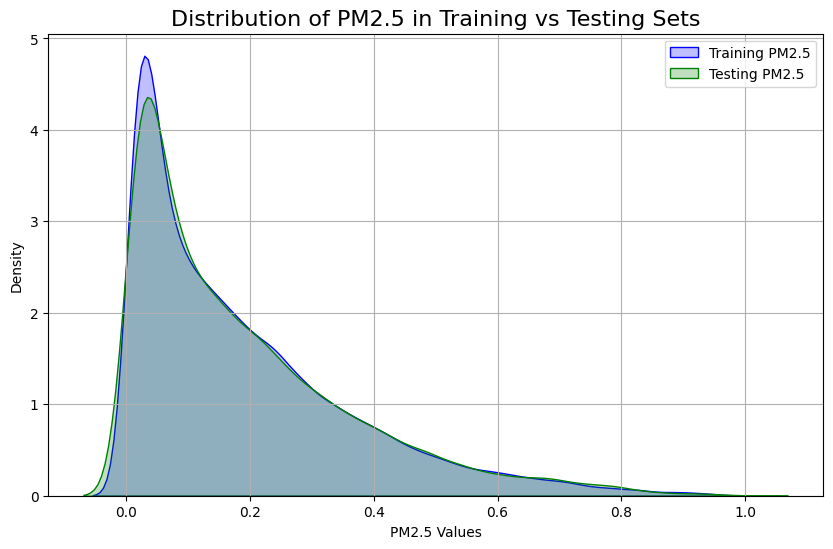

In [147]:


# Plotting the distribution of PM2.5 in training and testing sets
plt.figure(figsize=(10,6))

sns.kdeplot(y_train, label='Training PM2.5', shade=True, color='blue')
sns.kdeplot(y_test, label='Testing PM2.5', shade=True, color='green')

plt.title('Distribution of PM2.5 in Training vs Testing Sets', fontsize=16)
plt.xlabel('PM2.5 Values')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()


In [148]:
X_train = X_train.drop('datetime', axis=1) # Drop 'datetime' from X_train
X_test = X_test.drop('datetime', axis=1) # Drop 'datetime' from X_test

**Mean Absolute Error (MAE):** On average, how many predictions are accurate. (lower means more accurate)

**Root Mean Squared Errer (RMSE):** Measures the average difference between a statistical model's predicted values and the actual values. (lower means more accurate)

**R2 Score:** A statistical measure that indicates how well a regression model's predictions fit the actual data. (closer to 1 means more accurate)

## Linear Regression:

In [149]:
model = LinearRegression()

# Trainning the model
model.fit(X_train, y_train)

# Making predictions
y_pred = model.predict(X_test)

# Evaluating the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

mae_lin=mae
rmse_lin=rmse
r2_lin=r2

Model Evaluation Metrics:
Mean Absolute Error (MAE): 0.02
Root Mean Squared Error (RMSE): 0.03
R² Score: 0.98


## KNN Regression:

In [150]:
knn_model = KNeighborsRegressor(n_neighbors=3)
knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)

In [151]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R² Score: {r2}")

mae_knn = mae
rmse_knn = rmse
r2_knn = r2

Mean Absolute Error (MAE): 0.028281785491456785
Root Mean Squared Error (RMSE): 0.0404983719282423
R² Score: 0.9488909599055442


## SVR Model:

In [152]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build and train the SVR model
svr_model = SVR(kernel='rbf')  # You can also try 'linear' or 'poly'
svr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svr = svr_model.predict(X_test_scaled)

# Evaluate the SVR model
mae_svr = mean_absolute_error(y_test, y_pred_svr)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

print("SVR Model Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae_svr:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_svr:.2f}")
print(f"R² Score: {r2_svr:.2f}")

mae_svr=mae_svr
rmse_svr=rmse_svr
r2_svr=r2_svr

SVR Model Evaluation Metrics:
Mean Absolute Error (MAE): 0.03
Root Mean Squared Error (RMSE): 0.04
R² Score: 0.96


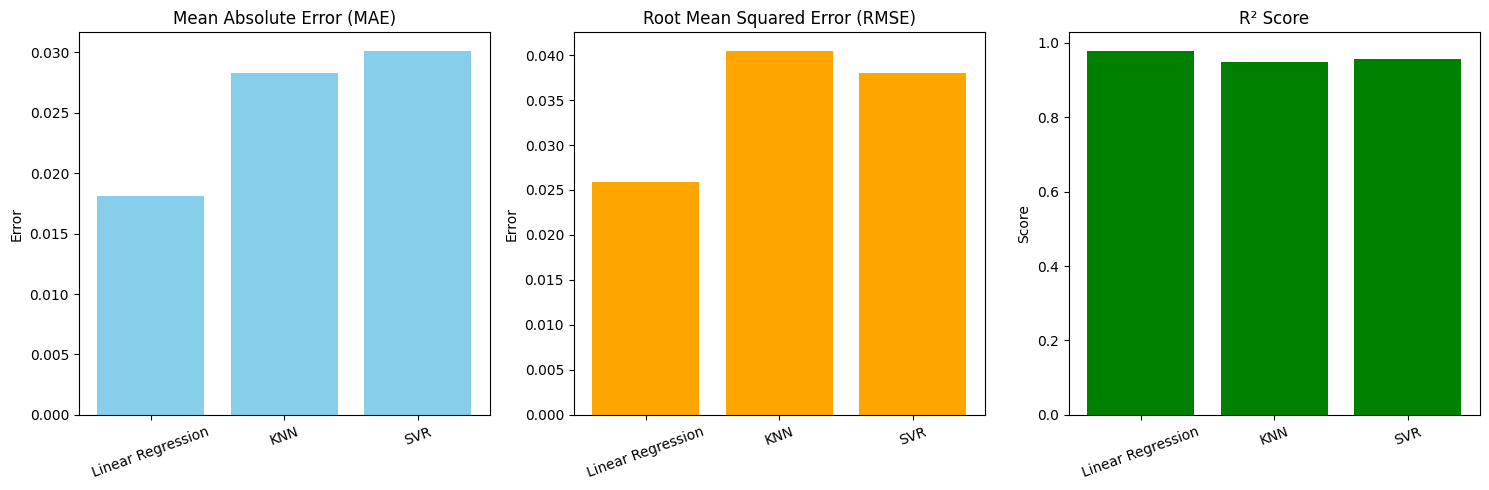

In [153]:
import matplotlib.pyplot as plt

# Model names
models = ['Linear Regression', 'KNN', 'SVR']

# Metric values (already in float)
mae_values = [mae_lin, mae_knn, mae_svr]
rmse_values = [rmse_lin, rmse_knn, rmse_svr]
r2_values = [r2_lin, r2_knn, r2_svr]

# Plotting
plt.figure(figsize=(15, 5))

# MAE
plt.subplot(1, 3, 1)
plt.bar(models, mae_values, color='skyblue')
plt.title('Mean Absolute Error (MAE)')
plt.ylabel('Error')
plt.xticks(rotation=20)

# RMSE
plt.subplot(1, 3, 2)
plt.bar(models, rmse_values, color='orange')
plt.title('Root Mean Squared Error (RMSE)')
plt.ylabel('Error')
plt.xticks(rotation=20)

# R² Score
plt.subplot(1, 3, 3)
plt.bar(models, r2_values, color='green')
plt.title('R² Score')
plt.ylabel('Score')
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


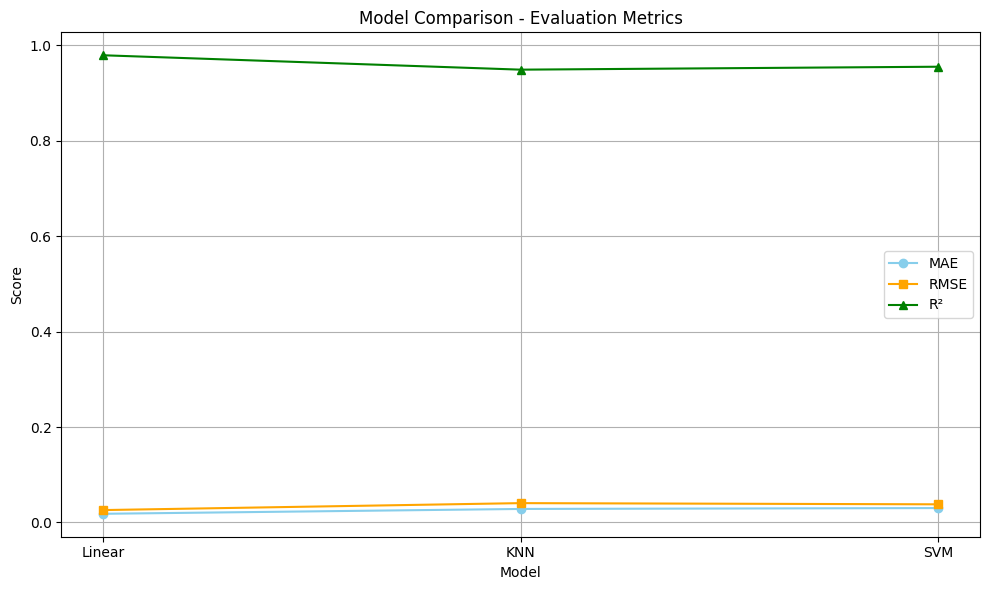

In [154]:
# Labels
models = ['Linear', 'KNN', 'SVM']

# Metrics
mae_values = [mae_lin, mae_knn, mae_svr]
rmse_values = [rmse_lin, rmse_knn, rmse_svr]
r2_values = [r2_lin, r2_knn, r2_svr]

plt.figure(figsize=(10, 6))

# Plot each metric
plt.plot(models, mae_values, marker='o', label='MAE', color='skyblue')
plt.plot(models, rmse_values, marker='s', label='RMSE', color='orange')
plt.plot(models, r2_values, marker='^', label='R²', color='green')

plt.title('Model Comparison - Evaluation Metrics')
plt.xlabel('Model')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


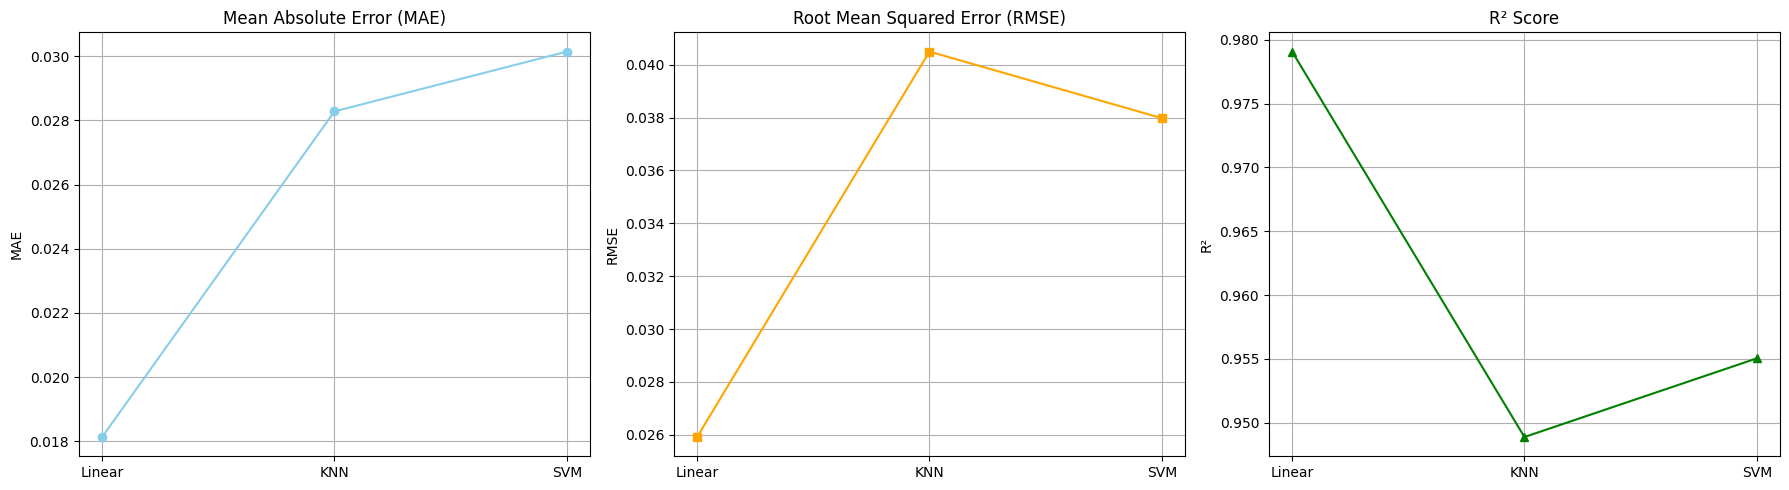

In [155]:
# Labels
models = ['Linear', 'KNN', 'SVM']

# Metric values
mae_values = [mae_lin, mae_knn, mae_svr]
rmse_values = [rmse_lin, rmse_knn, rmse_svr]
r2_values = [r2_lin, r2_knn, r2_svr]

plt.figure(figsize=(18, 5))

# MAE Plot
plt.subplot(1, 3, 1)
plt.plot(models, mae_values, marker='o', linestyle='-', color='skyblue')
plt.title('Mean Absolute Error (MAE)')
plt.ylabel('MAE')
plt.grid(True)

# RMSE Plot
plt.subplot(1, 3, 2)
plt.plot(models, rmse_values, marker='s', linestyle='-', color='orange')
plt.title('Root Mean Squared Error (RMSE)')
plt.ylabel('RMSE')
plt.grid(True)

# R² Plot
plt.subplot(1, 3, 3)
plt.plot(models, r2_values, marker='^', linestyle='-', color='green')
plt.title('R² Score')
plt.ylabel('R²')
plt.grid(True)

plt.tight_layout()
plt.show()


use 3 more models e.g SVM, DT, Random forest. perform hyperparameter. multi regression. create confusion matrix. and compare all.

## References:
->Zhang, Y., Cao, F., 2015. Fine particulate matter (PM2.5) in China at a city level. Chemosphere, 134, pp.85–90. Available at: https://www.sciencedirect.com/science/article/abs/pii/S0045653515300904

->Nirel, R., Dayan, U., 2001. On the Ratio of Sulfur Dioxide to Nitrogen Oxides as an Indicator of Air Pollution Sources. Journal of Applied Meteorology, 40(7), pp.1209–1221. Available at: https://journals.ametsoc.org/view/journals/apme/40/7/1520-0450_2001_040_1209_otrosd_2.0.co_2.xml